# Códigos para análise dos dados de LT

A seguir estão alguns testes que fiz desse código, mas a melhor versão é a última, logo vou utilizar apenas ela. O único problema dela é na leitura do arquivo txt, para ele ler sem nenhum problema tenho que deixar o arquivo bem limpo, e a melhor maneira de fazer isso é abrir o txt no excel, pegar as duas colunas que quero e jogar num txt de novo, sem nenhum texto antes (as vezes fica Coluna X escrito em cima).

## Códigos ruins

=== THERMAL LENS ANALYSIS ===

1. Reading oscilloscope data...
Pandas loading failed: No valid data found after pandas loading and cleaning.
Attempting manual loading as fallback.
   Time ranges from -0.0253 to 0.2229 s
   Intensity ranges from 0.0005 to 0.0104 V


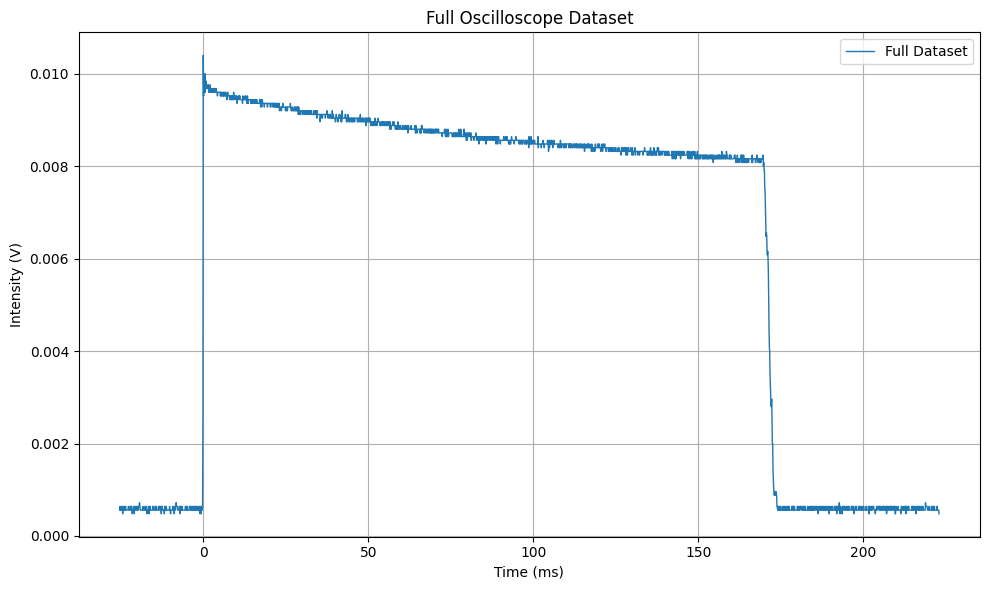


2. Identifying thermal lens region...
   Selected region indices: 253 to 1979
   Points in selected region: 1727
   Time range of selected region: 0.0000 to 0.1726 s

3. Removing edge points...
   Points after removing edges: 1677

4. Normalizing intensity...
   Normalized intensity range: 0.7833 to 1.0083

5. Estimating initial parameters...
   Initial Io: 1.0000
   Initial te: 3.0000e-04 s
   Initial tc: 8.3650e-02 s

6. Performing curve fit...
   Fit completed successfully!
   R² = 0.9262
   Chi²/DoF = 1.42e-04

=== FINAL RESULTS ===
Parameter	Value		Uncertainty
----------------------------------------
Io		0.61356	0.00041
te		1.00421e-06	0.00000e+00
tc		3.21886e-01	2.55223e-03
m		1.00000	0.00000 (fixed)
V		1.73000	0.00000 (fixed)

R²		= 0.9262
Chi²/DoF	= 1.42e-04
alpha = 1.942e-09 m^2/s, k = 0.008 W/m.K


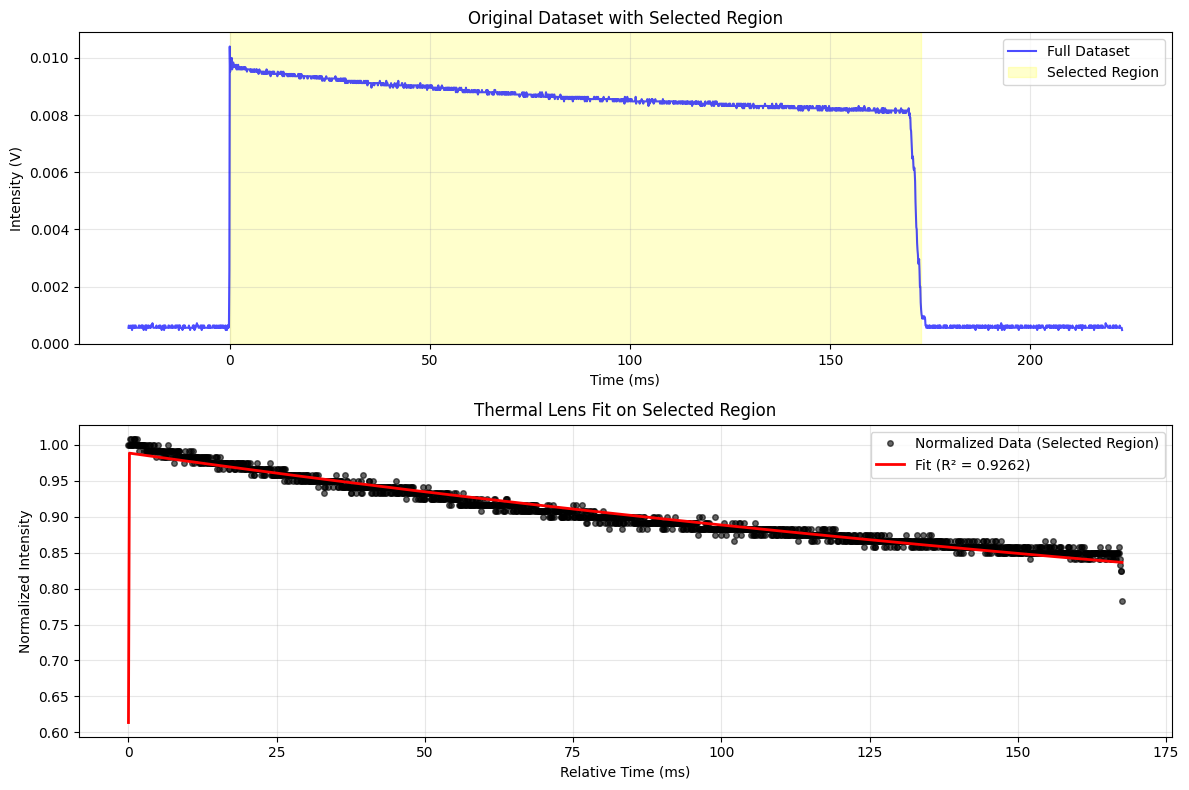

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

def thermal_lens_model(t, Io, te, tc, m=1, V=1.73):
    """
    Modelo da lente térmica
    t: tempo
    Io: intensidade inicial
    te: tempo característico de excitação
    tc: tempo característico de convecção
    m: parâmetro fixo (1)
    V: parâmetro fixo (1.73)
    """
    return Io * (1 + (m * V / (2 * np.sqrt(2))) *
                 ((1 - np.exp(-t/te))*np.exp(-t/tc)))

def read_oscilloscope_data(filename):
    """
    Lê os dados do osciloscópio do arquivo txt
    """
    try:
        # Attempt using pandas first
        # Assuming tab separator and no header based on previous file structures
        data_df = pd.read_csv(filename, sep='\t', header=None)
        # Assuming time is in the first column and intensity in the second (adjust if needed)
        # Convert to numeric, coercing errors to NaN
        time_vals = pd.to_numeric(data_df.iloc[:, 0], errors='coerce')
        intensity_vals = pd.to_numeric(data_df.iloc[:, 1], errors='coerce')

        # Combine into a DataFrame to easily drop rows with NaNs
        combined_df = pd.DataFrame({'time': time_vals, 'intensity': intensity_vals})
        combined_df = combined_df.dropna()

        # Convert to NumPy arrays and ensure float type
        time = combined_df['time'].values.astype(float)
        intensity = combined_df['intensity'].values.astype(float)

        if time.size == 0 or intensity.size == 0:
             raise ValueError("No valid data found after pandas loading and cleaning.")

        return time, intensity

    except Exception as e_pandas:
        print(f"Pandas loading failed: {e_pandas}")
        print("Attempting manual loading as fallback.")
        # Manual loading as fallback if pandas fails
        data = []
        with open(filename, 'r') as file:
            for line in file:
                line = line.strip()
                if line:
                    # Substitute comma decimal with period and split by tab
                    parts = line.replace(',', '.').split('\t')
                    # Assuming time is in the second to last column and intensity is in the last column
                    # Adjust indices if your file format is different
                    if len(parts) >= 2: # Ensure there are at least two columns
                        try:
                            time_val = float(parts[-2])
                            intensity_val = float(parts[-1])
                            data.append([time_val, intensity_val])
                        except (ValueError, IndexError):
                            # Skip lines that cannot be parsed into floats
                            continue

        if data:
            data_np = np.array(data, dtype=float) # Ensure conversion to float array
            return data_np[:, 0], data_np[:, 1]
        else:
            raise ValueError("No valid data found after manual loading.")


def find_thermal_lens_region(time, intensity, threshold_factor=0.7):
    """
    Encontra a região onde ocorre a lente térmica
    (região onde a intensidade está alta e depois decai)
    """
    if time.size == 0 or intensity.size == 0:
        return 0, -1 # Return empty range for empty data

    # Encontra o pico de intensidade
    max_idx = np.argmax(intensity)
    max_intensity = intensity[max_idx]

    # Define um threshold para encontrar onde a curva começa a ser significativa
    threshold = threshold_factor * max_intensity

    # Encontra o início da região significativa
    start_idx = 0
    for i in range(len(intensity)):
        if intensity[i] >= threshold:
            start_idx = i
            break

    # Encontra o final da região (quando a intensidade cai significativamente)
    end_idx = len(intensity) - 1
    # Find the minimum intensity after the peak
    min_after_peak = np.min(intensity[max_idx:]) if max_idx < len(intensity) else intensity[-1]


    # Define a lower threshold for the end of the decay
    end_threshold = min_after_peak + 0.1 * (max_intensity - min_after_peak)

    # Find the index where the intensity drops below the end_threshold after the peak
    end_idx = max_idx
    for i in range(max_idx, len(intensity)):
        if intensity[i] <= end_threshold:
            end_idx = i
            break
    # If no significant drop is found, use a point after the peak (e.g., 80% of remaining data)
    if end_idx == max_idx and max_idx < len(intensity) - 1:
         end_idx = max_idx + int(0.8 * (len(intensity) - 1 - max_idx))
         if end_idx >= len(intensity):
             end_idx = len(intensity) -1


    # Ensure start_idx is less than end_idx
    if start_idx >= end_idx:
        # Fallback to a simpler selection if the above logic fails
        print("Warning: Automatic region selection failed. Using fallback selection.")
        start_idx = np.argmax(intensity > (np.min(intensity) + 0.3 * (np.max(intensity) - np.min(intensity))))
        end_idx = len(intensity) - 1 # Use the end of the data as fallback end


    # Ensure we have a reasonable number of points
    if end_idx - start_idx < 10:
         print("Warning: Selected region is too small. Consider adjusting threshold or data.")
         # As a last resort fallback, select a fixed percentage of data after the peak
         if max_idx < len(intensity) - 1:
            start_idx = max_idx
            end_idx = max_idx + int(0.5 * (len(intensity) - 1 - max_idx))
            if end_idx >= len(intensity):
                end_idx = len(intensity) - 1
            if end_idx <= start_idx: # ensure at least one point after start
                 if start_idx < len(intensity) -1:
                     end_idx = start_idx + 1
                 else: # start is the last point
                     start_idx = len(intensity) - 2
                     end_idx = len(intensity) - 1
    # Ensure start_idx is not negative
    if start_idx < 0:
        start_idx = 0


    return start_idx, end_idx

def remove_edge_points(time, intensity, edge_points=5):
    """
    Remove points from the extremities that can interfere with the fit
    """
    if len(time) > 2 * edge_points:
        return time[edge_points:-edge_points], intensity[edge_points:-edge_points]
    else:
        return time, intensity

def normalize_intensity(intensity):
    """
    Normalizes the intensity using the first point as a reference
    """
    if len(intensity) > 0 and intensity[0] != 0:
        return intensity / intensity[0]
    else:
        return intensity # Return as is if empty or first point is zero

def estimate_initial_parameters(time, intensity_norm):
    """
    Estimates initial parameters for fitting
    """
    if len(time) == 0 or len(intensity_norm) == 0:
         return 1.0, 0.01, 0.05 # Return default values for empty data

    Io_initial = intensity_norm[0]  # First point (should be ~1 after normalization)

    # Estimate te as the time where intensity reaches maximum (relative time)
    max_idx = np.argmax(intensity_norm)
    if max_idx == 0 and len(time) > 1: # If max is the first point, te is likely small
         te_initial = (time[1] - time[0]) * 10 # Small time guess
    elif max_idx > 0:
        te_initial = time[max_idx] - time[0]
    else: # Only one data point or other issue
        te_initial = 0.01 # Default small value

    if te_initial <= 0: # Ensure te is positive
        te_initial = 0.001 # Use a small positive value

    # Estimate tc based on decay time
    # Look for where intensity drops to ~37% of the initial value after the maximum
    target_val = Io_initial * 0.37

    # Search for the decay point after the peak
    decay_idx = -1
    for i in range(max_idx, len(intensity_norm)):
        if intensity_norm[i] <= target_val:
            decay_idx = i
            break

    if decay_idx != -1 and decay_idx > max_idx:
        tc_initial = time[decay_idx] - time[max_idx]
    elif len(time) > max_idx + 1: # If no clear 37% drop, use a characteristic time based on the range after peak
        tc_initial = (time[-1] - time[max_idx]) / 2.0 if time[-1] > time[max_idx] else 0.05
    else: # Fallback
        tc_initial = 0.05


    if tc_initial <= 0: # Ensure tc is positive
         tc_initial = 0.01 # Use a small positive value


    # Amplitude guess: difference between initial and final intensity in the selected region
    A_initial = 1.0 - intensity_norm[-1] if len(intensity_norm) > 0 else 0.1
    if A_initial < 0.01: A_initial = 0.01 # Ensure a minimum amplitude guess

    return Io_initial, te_initial, tc_initial

def perform_curve_fit(time, intensity_norm, initial_params, max_fev=10000):
    """
    Performs the curve fit with retry mechanism and improved bounds
    """
    Io_init, te_init, tc_init = initial_params

    # Improved bounds based on typical thermal lens decay
    # Io should be around 1 after normalization
    # te (excitation time) should be small positive
    # tc (convection time) should be positive and typically larger than te
    # A (amplitude) should be positive and less than 1.0 for decay
    bounds = (
        [0.5, 1e-6, 1e-6],    # Lower bounds for [Io, te, tc]
        [1.5, time[-1], time[-1] * 10]  # Upper bounds for [Io, te, tc] - te and tc should be within reasonable range of data
    )

    p0 = [Io_init, te_init, tc_init]


    try:
        popt, pcov = curve_fit(thermal_lens_model, time, intensity_norm,
                             p0=p0, bounds=bounds, maxfev=max_fev)
        return popt, pcov

    except RuntimeError as e:
        print(f"Curve fit failed: {e}")
        print("Attempting fit with adjusted bounds and initial guesses.")
        # Retry with wider bounds and slightly adjusted initial guesses
        bounds_retry = (
            [0.1, 1e-9, 1e-9],
            [2.0, time[-1] * 2, time[-1] * 20]
        )
        p0_retry = [1.0, (time[-1]-time[0])/10.0, (time[-1]-time[0])/2.0] # More general guesses

        try:
             popt, pcov = curve_fit(thermal_lens_model, time, intensity_norm,
                                 p0=p0_retry, bounds=bounds_retry, maxfev=max_fev * 2)
             return popt, pcov
        except Exception as e_retry:
             print(f"Curve fit failed even after retry: {e_retry}")
             raise e_retry # Re-raise the exception if retry also fails



# Função principal de análise
def analyze_thermal_lens(filename):
    """
    Main function to perform thermal lens analysis
    """
    print("=== THERMAL LENS ANALYSIS ===\n")

    # Step 1: Read data
    print("1. Reading oscilloscope data...")
    try:
        time_full, intensity_full = read_oscilloscope_data(filename)
        print(f"   Time ranges from {time_full[0]:.4f} to {time_full[-1]:.4f} s")
        print(f"   Intensity ranges from {intensity_full.min():.4f} to {intensity_full.max():.4f} V")
    except Exception as e:
        print(f"   Error reading file: {e}")
        print("   Please check if the file exists and is in the correct format.")
        return

    # Plot full dataset
    plt.figure(figsize=(10, 6))
    plt.plot(time_full * 1e3, intensity_full, '-', lw=1.0, label="Full Dataset")
    plt.xlabel("Time (ms)")
    plt.ylabel("Intensity (V)")
    plt.title("Full Oscilloscope Dataset")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # Step 2: Select thermal lens region (using updated function)
    print("\n2. Identifying thermal lens region...")
    start_idx, end_idx = find_thermal_lens_region(time_full, intensity_full)
    if start_idx >= end_idx:
         raise RuntimeError("Could not identify a valid thermal lens region.")

    time_region = time_full[start_idx:end_idx+1]
    intensity_region = intensity_full[start_idx:end_idx+1]
    print(f"   Selected region indices: {start_idx} to {end_idx}")
    print(f"   Points in selected region: {len(time_region)}")
    print(f"   Time range of selected region: {time_region[0]:.4f} to {time_region[-1]:.4f} s")


    # Remove edge points (optional)
    print("\n3. Removing edge points...")
    # Increased edge_points to 10 for more aggressive removal
    time_clean, intensity_clean = remove_edge_points(time_region, intensity_region, edge_points=25) # Increased edge_points to 25
    print(f"   Points after removing edges: {len(time_clean)}")


    # Step 3: Normalize intensity
    print("\n4. Normalizing intensity...")
    intensity_norm = normalize_intensity(intensity_clean)
    if len(intensity_norm) == 0:
         raise RuntimeError("No data remaining after normalization.")
    print(f"   Normalized intensity range: {intensity_norm.min():.4f} to {intensity_norm.max():.4f}")


    # Step 4: Estimate initial parameters
    print("\n5. Estimating initial parameters...")
    try:
        Io_init, te_init, tc_init = estimate_initial_parameters(time_clean, intensity_norm)
        print(f"   Initial Io: {Io_init:.4f}")
        print(f"   Initial te: {te_init:.4e} s")
        print(f"   Initial tc: {tc_init:.4e} s")
    except Exception as e:
        print(f"   Error estimating initial parameters: {e}")
        # Provide some default fallback parameters if estimation fails
        Io_init, te_init, tc_init = 1.0, (time_clean[-1]-time_clean[0])/10.0, (time_clean[-1]-time_clean[0])/2.0
        print(f"   Using fallback initial parameters: Io={Io_init:.4f}, te={te_init:.4e}, tc={tc_init:.4e}")


    # Step 5: Curve fitting
    print("\n6. Performing curve fit...")
    try:
        best_params, best_cov = perform_curve_fit(
            time_clean - time_clean[0], intensity_norm, (Io_init, te_init, tc_init)) # Fit against relative time


        Io_fit, te_fit, tc_fit = best_params

        # Calculate uncertainties
        param_errors = np.sqrt(np.diag(best_cov))
        Io_err, te_err, tc_err = param_errors

        print("   Fit completed successfully!")


        # Calculate R² and Chi²/DoF
        y_pred = thermal_lens_model(time_clean - time_clean[0], *best_params) # Predict using relative time
        residuals = intensity_norm - y_pred
        chi_squared = np.sum(residuals**2)
        # Ensure degrees of freedom is at least 1
        dof = max(1, len(time_clean) - len(best_params))  # Number of data points - number of fitted parameters
        chi_squared_dof = chi_squared / dof

        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((intensity_norm - np.mean(intensity_norm))**2)
        # Avoid division by zero if ss_tot is zero
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0


        print(f"   R² = {r_squared:.4f}")
        print(f"   Chi²/DoF = {chi_squared_dof:.2e}")


    except Exception as e:
        print(f"   Error during curve fitting: {e}")
        return


    # Final Results
    print("\n=== FINAL RESULTS ===")
    print("Parameter\tValue\t\tUncertainty")
    print("-" * 40)
    print(f"Io\t\t{Io_fit:.5f}\t{Io_err:.5f}")
    print(f"te\t\t{te_fit:.5e}\t{te_err:.5e}") # Display te in scientific notation
    print(f"tc\t\t{tc_fit:.5e}\t{tc_err:.5e}") # Display tc in scientific notation
    print(f"m\t\t1.00000\t0.00000 (fixed)")
    print(f"V\t\t1.73000\t0.00000 (fixed)")
    print(f"\nR²\t\t= {r_squared:.4f}")
    print(f"Chi²/DoF\t= {chi_squared_dof:.2e}")

    # Calculate physical parameters
    # w0, rho, Cp defined at the beginning
    if tc_fit > 0: # Ensure tc is positive before calculating alpha and k
        alpha = w0**2 / (4.0 * tc_fit)
        k = alpha * rho * Cp
        print(f"alpha = {alpha:.3e} m^2/s, k = {k:.3f} W/m.K")
    else:
        print("Cannot calculate alpha and k: tc is not positive.")


    # Plotting results
    plt.figure(figsize=(12, 8))

    # Plot 1: Original data with selected region
    plt.subplot(2, 1, 1) # Change to 2 rows, 1 column for stacked plots
    plt.plot(time_full * 1e3, intensity_full, 'b-', alpha=0.7, label='Full Dataset')
    plt.axvspan(time_region[0] * 1e3, time_region[-1] * 1e3, alpha=0.2, color='yellow',
                label='Selected Region')
    plt.xlabel('Time (ms)')
    plt.ylabel('Intensity (V)')
    plt.title('Original Dataset with Selected Region')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Normalized selected data and fit
    plt.subplot(2, 1, 2) # Second plot in the 2x1 grid
    plt.plot((time_clean - time_clean[0]) * 1e3, intensity_norm, 'ko', markersize=4, alpha=0.6, label='Normalized Data (Selected Region)')

    # Fitted curve
    time_fit = np.linspace(0, (time_clean[-1] - time_clean[0]), 1000) # Fit against relative time
    intensity_fit = thermal_lens_model(time_fit, *best_params)
    plt.plot(time_fit * 1e3, intensity_fit, 'r-', linewidth=2, label=f'Fit (R² = {r_squared:.4f})')

    plt.xlabel('Relative Time (ms)') # Label relative time
    plt.ylabel('Normalized Intensity')
    plt.title('Thermal Lens Fit on Selected Region')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'Io': (Io_fit, Io_err),
        'te': (te_fit, te_err),
        'tc': (tc_fit, tc_err),
        'r_squared': r_squared,
        'chi_squared_dof': chi_squared_dof,
        'time_clean': time_clean,
        'intensity_norm': intensity_norm,
        'fitted_curve': thermal_lens_model(time_clean - time_clean[0], *best_params) # Return fit for relative time
    }

# Execute the analysis
if __name__ == "__main__":
    filename = "dados_osciloscopio66.txt"
    results = analyze_thermal_lens(filename)

=== ANÁLISE DE LENTE TÉRMICA ===

1. Lendo dados do osciloscópio...
   Total de linhas no arquivo: 2484
   Linha 1: ''
   Linha 2: '-0,0253	0,00056'
   Linha 3: '-0,0252	0,00064'
   Linha 4: '-0,0251	0,00056'
   Linha 5: '-0,025	0,00056'
   Debug linha 2: tempo='-0,0253', intensidade='0,00056'
   Debug linha 3: tempo='-0,0252', intensidade='0,00064'
   Dados válidos processados: 2483 pontos
   Tipo dos dados de tempo: float64
   Tipo dos dados de intensidade: float64
   Primeiros 3 valores de tempo: [-0.0253 -0.0252 -0.0251]
   Primeiros 3 valores de intensidade: [0.00056 0.00064 0.00056]
   Tempo vai de -0.025300 a 0.222900 s
   Intensidade vai de 0.000480 a 0.010400

2. Identificando região da lente térmica...
   Região selecionada: índices 253 a 1979
   Pontos na região: 1727

3. Removendo pontos das extremidades...
   Pontos após limpeza: 1717

4. Normalizando intensidade...
   Intensidade normalizada: 1.0000 a 0.2800

5. Estimando parâmetros iniciais...
   Debug: tipo time = <clas

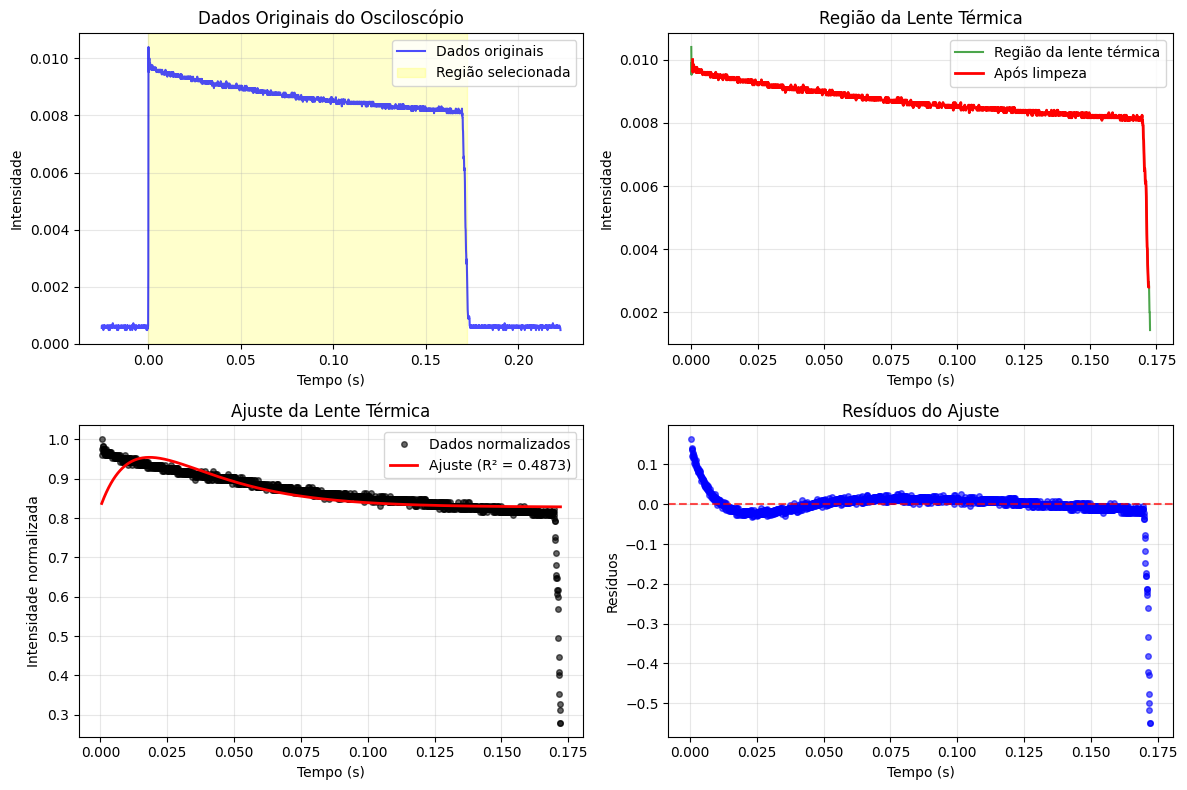

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re

def thermal_lens_model(t, Io, te, tc, m=1, V=1.73):
    """
    Modelo da lente térmica
    t: tempo
    Io: intensidade inicial
    te: tempo característico de excitação
    tc: tempo característico de convecção
    m: parâmetro fixo (1)
    V: parâmetro fixo (1.73)
    """
    return Io * (1 + (m * V / (2 * np.sqrt(2))) *
                 ((1 - np.exp(-t/te))*np.exp(-t/tc)))

def read_oscilloscope_data(filename):
    """
    Lê os dados do osciloscópio do arquivo txt
    """
    data = []

    try:
        with open(filename, 'r', encoding='utf-8') as file:
            lines = file.readlines()
    except Exception as e:
        raise ValueError(f"Erro ao abrir o arquivo: {e}")

    print(f"   Total de linhas no arquivo: {len(lines)}")

    # Mostra as primeiras linhas para debug
    for i, line in enumerate(lines[:5]):
        print(f"   Linha {i+1}: '{line.strip()}'")

    for i, line in enumerate(lines):
        line = line.strip()
        if not line:  # Pula linhas vazias
            continue

        try:
            # Tenta diferentes separadores
            if '\t' in line:
                parts = line.split('\t')
            elif '  ' in line:  # Múltiplos espaços
                parts = [p for p in line.split() if p]
            elif ' ' in line:
                parts = [p for p in line.split(' ') if p]
            else:
                continue

            if len(parts) >= 2:
                # Pega apenas os dois primeiros valores
                time_str = str(parts[0]).strip()
                intensity_str = str(parts[1]).strip()

                # Debug para as primeiras linhas
                if i < 3:
                    print(f"   Debug linha {i+1}: tempo='{time_str}', intensidade='{intensity_str}'")

                # Converte vírgulas decimais para pontos
                time_str = time_str.replace(',', '.')
                intensity_str = intensity_str.replace(',', '.')

                # Remove qualquer caractere não numérico exceto . - + e E
                time_str = re.sub(r'[^\d\.\-\+eE]', '', time_str)
                intensity_str = re.sub(r'[^\d\.\-\+eE]', '', intensity_str)

                if time_str and intensity_str and time_str != '.' and intensity_str != '.':
                    try:
                        # Converte IMEDIATAMENTE para float
                        time_val = float(time_str)
                        intensity_val = float(intensity_str)

                        # Verifica se são valores válidos
                        if np.isfinite(time_val) and np.isfinite(intensity_val):
                            data.append([time_val, intensity_val])

                    except ValueError as ve:
                        if i < 5:
                            print(f"   Erro conversão linha {i+1}: {ve}")
                        continue

        except Exception as e:
            if i < 5:
                print(f"   Aviso: Linha {i+1} ignorada - erro: {str(e)}")
            continue

    if not data:
        raise ValueError("Nenhum dado válido encontrado no arquivo")

    # Converte para array numpy garantindo tipo float
    data_array = np.array(data, dtype=np.float64)
    print(f"   Dados válidos processados: {len(data_array)} pontos")

    # Separa tempo e intensidade
    time_data = data_array[:, 0]
    intensity_data = data_array[:, 1]

    print(f"   Tipo dos dados de tempo: {time_data.dtype}")
    print(f"   Tipo dos dados de intensidade: {intensity_data.dtype}")
    print(f"   Primeiros 3 valores de tempo: {time_data[:3]}")
    print(f"   Primeiros 3 valores de intensidade: {intensity_data[:3]}")

    return time_data, intensity_data

def find_thermal_lens_region(time, intensity, threshold_factor=0.7):
    """
    Encontra a região onde ocorre a lente térmica
    """
    max_idx = np.argmax(intensity)
    max_intensity = intensity[max_idx]

    threshold = threshold_factor * max_intensity

    # Encontra o início da região significativa
    start_idx = 0
    for i in range(len(intensity)):
        if intensity[i] >= threshold:
            start_idx = i
            break

    # Encontra o final da região
    end_idx = len(intensity) - 1
    min_after_peak = np.min(intensity[max_idx:])

    for i in range(max_idx, len(intensity)):
        if intensity[i] <= min_after_peak + 0.1 * (max_intensity - min_after_peak):
            end_idx = i
            break

    return start_idx, end_idx

def remove_edge_points(time, intensity, edge_points=5):
    """
    Remove pontos das extremidades
    """
    if len(time) > 2 * edge_points:
        return time[edge_points:-edge_points], intensity[edge_points:-edge_points]
    else:
        return time, intensity

def normalize_intensity(intensity):
    """
    Normaliza a intensidade usando o primeiro ponto como referência
    """
    # Garante que intensity é um array numpy de float
    intensity_array = np.array(intensity, dtype=np.float64)
    return intensity_array / intensity_array[0]

def estimate_initial_parameters(time, intensity_norm):
    """
    Estima os parâmetros iniciais para o ajuste
    """
    print(f"   Debug: tipo time = {type(time)}, tipo intensity_norm = {type(intensity_norm)}")

    # Garante que são arrays numpy de float (já devem ser da função de leitura)
    time_array = np.asarray(time, dtype=np.float64)
    intensity_array = np.asarray(intensity_norm, dtype=np.float64)

    print(f"   Debug: após conversão - time[0] = {time_array[0]}, intensity[0] = {intensity_array[0]}")

    Io_initial = float(intensity_array[0])

    # Estima te
    max_idx = np.argmax(intensity_array)
    te_initial = abs(float(time_array[max_idx]) - float(time_array[0]))
    if te_initial == 0:
        te_initial = 0.01

    # Estima tc
    max_val = np.max(intensity_array)
    target_val = max_val * 0.37
    tc_initial = te_initial * 2

    for i in range(max_idx, len(intensity_array)):
        if intensity_array[i] <= target_val:
            tc_initial = abs(float(time_array[i]) - float(time_array[max_idx]))
            break

    if tc_initial == 0:
        tc_initial = 0.05

    return float(Io_initial), float(te_initial), float(tc_initial)

def perform_curve_fit(time, intensity_norm, initial_params, max_iterations=100):
    """
    Realiza o ajuste de curva
    """
    Io_init, te_init, tc_init = initial_params

    bounds = ([0.8, 0.001, 0.001], [1.2, 1.0, 1.0])

    best_params = None
    best_cov = None
    best_r_squared = 0

    for iteration in range(max_iterations):
        try:
            noise_factor = 0.1 * (iteration / max_iterations)
            Io_try = Io_init * (1 + np.random.normal(0, noise_factor))
            te_try = te_init * (1 + np.random.normal(0, noise_factor))
            tc_try = tc_init * (1 + np.random.normal(0, noise_factor))

            Io_try = np.clip(Io_try, bounds[0][0], bounds[1][0])
            te_try = np.clip(te_try, bounds[0][1], bounds[1][1])
            tc_try = np.clip(tc_try, bounds[0][2], bounds[1][2])

            p0 = [Io_try, te_try, tc_try]

            popt, pcov = curve_fit(thermal_lens_model, time, intensity_norm,
                                 p0=p0, bounds=bounds, maxfev=5000)

            y_pred = thermal_lens_model(time, *popt)
            ss_res = np.sum((intensity_norm - y_pred) ** 2)
            ss_tot = np.sum((intensity_norm - np.mean(intensity_norm)) ** 2)
            r_squared = 1 - (ss_res / ss_tot)

            if r_squared > best_r_squared:
                best_params = popt
                best_cov = pcov
                best_r_squared = r_squared

        except Exception as e:
            continue

    if best_params is None:
        raise ValueError("Não foi possível realizar o ajuste de curva")

    return best_params, best_cov, best_r_squared

def analyze_thermal_lens(filename):
    """
    Função principal de análise
    """
    print("=== ANÁLISE DE LENTE TÉRMICA ===\n")

    # Passo 1: Ler os dados
    print("1. Lendo dados do osciloscópio...")
    try:
        time, intensity = read_oscilloscope_data(filename)
        print(f"   Tempo vai de {time[0]:.6f} a {time[-1]:.6f} s")
        print(f"   Intensidade vai de {intensity.min():.6f} a {intensity.max():.6f}")
    except Exception as e:
        print(f"   Erro ao ler arquivo: {e}")
        print("   Verifique se o arquivo existe e está no formato correto.")
        return

    # Passo 2: Separar região da lente térmica
    print("\n2. Identificando região da lente térmica...")
    start_idx, end_idx = find_thermal_lens_region(time, intensity)
    time_region = time[start_idx:end_idx+1]
    intensity_region = intensity[start_idx:end_idx+1]
    print(f"   Região selecionada: índices {start_idx} a {end_idx}")
    print(f"   Pontos na região: {len(time_region)}")

    # Remove pontos das extremidades
    print("\n3. Removendo pontos das extremidades...")
    time_clean, intensity_clean = remove_edge_points(time_region, intensity_region)
    print(f"   Pontos após limpeza: {len(time_clean)}")

    # Passo 3: Normalizar intensidade
    print("\n4. Normalizando intensidade...")
    intensity_norm = normalize_intensity(intensity_clean)
    print(f"   Intensidade normalizada: {intensity_norm[0]:.4f} a {intensity_norm[-1]:.4f}")

    # Passo 4: Estimar parâmetros iniciais
    print("\n5. Estimando parâmetros iniciais...")
    Io_init, te_init, tc_init = estimate_initial_parameters(time_clean, intensity_norm)
    print(f"   Io inicial: {Io_init:.4f}")
    print(f"   te inicial: {te_init:.4f} s")
    print(f"   tc inicial: {tc_init:.4f} s")

    # Passo 5: Ajuste de curva
    print("\n6. Realizando ajuste de curva (100 iterações)...")
    try:
        best_params, best_cov, r_squared = perform_curve_fit(
            time_clean, intensity_norm, (Io_init, te_init, tc_init))

        Io_fit, te_fit, tc_fit = best_params
        param_errors = np.sqrt(np.diag(best_cov))
        Io_err, te_err, tc_err = param_errors

        print("   Ajuste concluído com sucesso!")
        print(f"   R² = {r_squared:.4f}")

        # Calcula chi²/DoF
        y_pred = thermal_lens_model(time_clean, *best_params)
        residuals = intensity_norm - y_pred
        chi_squared = np.sum(residuals**2)
        dof = len(time_clean) - 3
        chi_squared_dof = chi_squared / dof

        print(f"   Chi²/DoF = {chi_squared_dof:.2e}")

    except Exception as e:
        print(f"   Erro no ajuste: {e}")
        return

    # Resultados finais
    print("\n=== RESULTADOS FINAIS ===")
    print("Parâmetro\tValor\t\tIncerteza")
    print("-" * 40)
    print(f"Io\t\t{Io_fit:.5f}\t{Io_err:.5f}")
    print(f"te\t\t{te_fit:.5f}\t{te_err:.5f}")
    print(f"tc\t\t{tc_fit:.5f}\t{tc_err:.5f}")
    print(f"m\t\t1.00000\t0.00000 (fixo)")
    print(f"V\t\t1.73000\t0.00000 (fixo)")
    print(f"\nR²\t\t= {r_squared:.4f}")
    print(f"Chi²/DoF\t= {chi_squared_dof:.2e}")

    # Plotagem dos resultados
    plt.figure(figsize=(12, 8))

    # Plot 1: Dados originais
    plt.subplot(2, 2, 1)
    plt.plot(time, intensity, 'b-', alpha=0.7, label='Dados originais')
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.2, color='yellow',
                label='Região selecionada')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade')
    plt.title('Dados Originais do Osciloscópio')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Região selecionada
    plt.subplot(2, 2, 2)
    plt.plot(time_region, intensity_region, 'g-', alpha=0.7, label='Região da lente térmica')
    plt.plot(time_clean, intensity_clean, 'r-', linewidth=2, label='Após limpeza')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade')
    plt.title('Região da Lente Térmica')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Dados normalizados e ajuste
    plt.subplot(2, 2, 3)
    plt.plot(time_clean, intensity_norm, 'ko', markersize=4, alpha=0.6, label='Dados normalizados')

    # Curva ajustada
    time_fit = np.linspace(time_clean.min(), time_clean.max(), 1000)
    intensity_fit = thermal_lens_model(time_fit, *best_params)
    plt.plot(time_fit, intensity_fit, 'r-', linewidth=2, label=f'Ajuste (R² = {r_squared:.4f})')

    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade normalizada')
    plt.title('Ajuste da Lente Térmica')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 4: Resíduos
    plt.subplot(2, 2, 4)
    y_pred = thermal_lens_model(time_clean, *best_params)
    residuals = intensity_norm - y_pred
    plt.plot(time_clean, residuals, 'bo', markersize=4, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Resíduos')
    plt.title('Resíduos do Ajuste')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'Io': (Io_fit, Io_err),
        'te': (te_fit, te_err),
        'tc': (tc_fit, tc_err),
        'r_squared': r_squared,
        'chi_squared_dof': chi_squared_dof,
        'time': time_clean,
        'intensity_norm': intensity_norm,
        'fitted_curve': thermal_lens_model(time_clean, *best_params)
    }

# Executar a análise
if __name__ == "__main__":
    filename = "dados_osciloscopio66.txt"
    results = analyze_thermal_lens(filename)

=== ANÁLISE DE LENTE TÉRMICA ===

1. Lendo dados do osciloscópio...
   Total de linhas no arquivo: 2483
   Linha 1: '-0,0253	0,00056'
   Linha 2: '-0,0252	0,00032'
   Linha 3: '-0,0251	0,00048'
   Linha 4: '-0,025	0,00056'
   Linha 5: '-0,0249	0,00048'
   Debug linha 1: tempo='-0,0253', intensidade='0,00056'
   Debug linha 2: tempo='-0,0252', intensidade='0,00032'
   Debug linha 3: tempo='-0,0251', intensidade='0,00048'
   Dados válidos processados: 2483 pontos
   Tipo dos dados de tempo: float64
   Tipo dos dados de intensidade: float64
   Primeiros 3 valores de tempo: [-0.0253 -0.0252 -0.0251]
   Primeiros 3 valores de intensidade: [0.00056 0.00032 0.00048]
   Tempo vai de -0.025300 a 0.222900 s
   Intensidade vai de 0.000240 a 0.014080

2. Identificando região da lente térmica...
   Região selecionada: índices 254 a 2010
   Pontos na região: 1757

3. Removendo pontos das extremidades...
   Pontos após limpeza: 1747

4. Normalizando intensidade...
   Intensidade normalizada: 1.0000 a

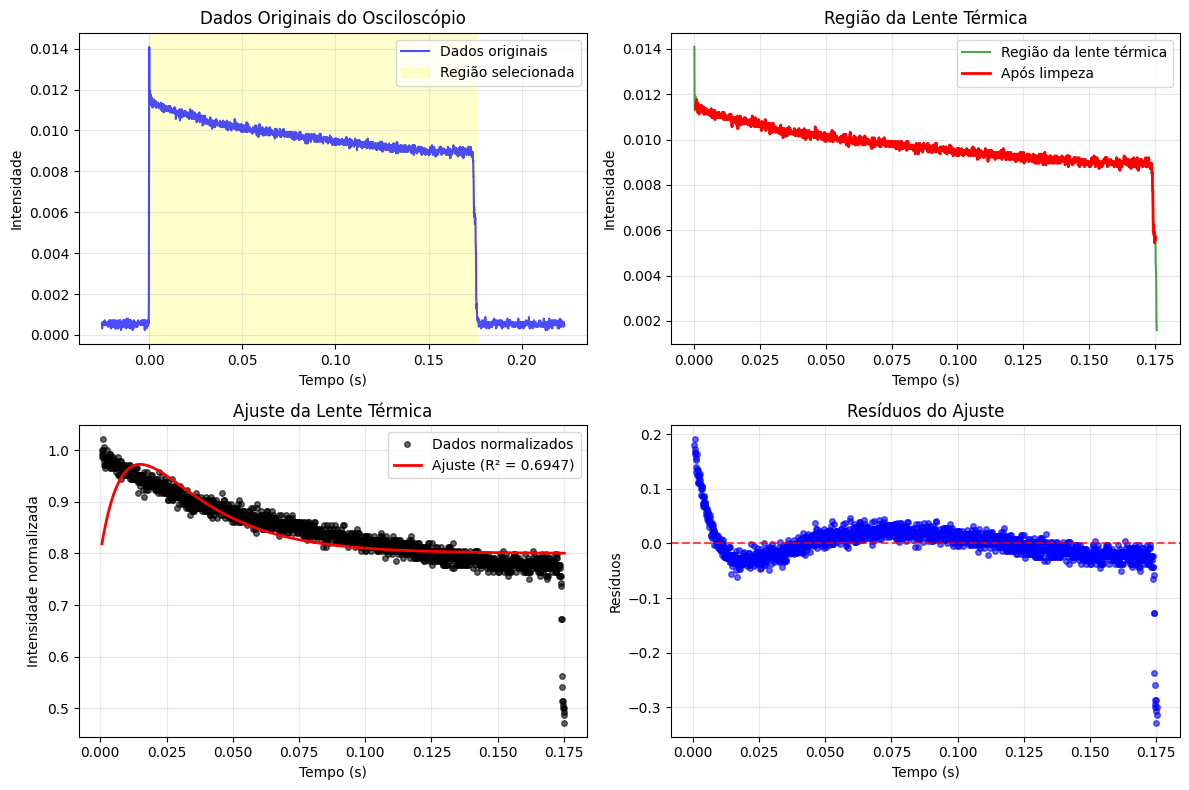

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re

def thermal_lens_model(t, Io, te, tc, m=1, V=1.73):
    """
    Modelo da lente térmica
    t: tempo
    Io: intensidade inicial
    te: tempo característico de excitação
    tc: tempo característico de convecção
    m: parâmetro fixo (1)
    V: parâmetro fixo (1.73)
    """
    return Io * (1 + (m * V / (2 * np.sqrt(2))) *
                 ((1 - np.exp(-t/te))*np.exp(-t/tc)))

def read_oscilloscope_data(filename):
    """
    Lê os dados do osciloscópio do arquivo txt
    """
    data = []

    try:
        with open(filename, 'r', encoding='utf-8') as file:
            lines = file.readlines()
    except Exception as e:
        raise ValueError(f"Erro ao abrir o arquivo: {e}")

    print(f"   Total de linhas no arquivo: {len(lines)}")

    # Mostra as primeiras linhas para debug
    for i, line in enumerate(lines[:5]):
        print(f"   Linha {i+1}: '{line.strip()}'")

    for i, line in enumerate(lines):
        line = line.strip()
        if not line:  # Pula linhas vazias
            continue

        try:
            # Tenta diferentes separadores
            if '\t' in line:
                parts = line.split('\t')
            elif '  ' in line:  # Múltiplos espaços
                parts = [p for p in line.split() if p]
            elif ' ' in line:
                parts = [p for p in line.split(' ') if p]
            else:
                continue

            if len(parts) >= 2:
                # Pega apenas os dois primeiros valores
                time_str = str(parts[0]).strip()
                intensity_str = str(parts[1]).strip()

                # Debug para as primeiras linhas
                if i < 3:
                    print(f"   Debug linha {i+1}: tempo='{time_str}', intensidade='{intensity_str}'")

                # Converte vírgulas decimais para pontos
                time_str = time_str.replace(',', '.')
                intensity_str = intensity_str.replace(',', '.')

                # Remove qualquer caractere não numérico exceto . - + e E
                time_str = re.sub(r'[^\d\.\-\+eE]', '', time_str)
                intensity_str = re.sub(r'[^\d\.\-\+eE]', '', intensity_str)

                if time_str and intensity_str and time_str != '.' and intensity_str != '.':
                    try:
                        # Converte IMEDIATAMENTE para float
                        time_val = float(time_str)
                        intensity_val = float(intensity_str)

                        # Verifica se são valores válidos
                        if np.isfinite(time_val) and np.isfinite(intensity_val):
                            data.append([time_val, intensity_val])

                    except ValueError as ve:
                        if i < 5:
                            print(f"   Erro conversão linha {i+1}: {ve}")
                        continue

        except Exception as e:
            if i < 5:
                print(f"   Aviso: Linha {i+1} ignorada - erro: {str(e)}")
            continue

    if not data:
        raise ValueError("Nenhum dado válido encontrado no arquivo")

    # Converte para array numpy garantindo tipo float
    data_array = np.array(data, dtype=np.float64)
    print(f"   Dados válidos processados: {len(data_array)} pontos")

    # Separa tempo e intensidade
    time_data = data_array[:, 0]
    intensity_data = data_array[:, 1]

    print(f"   Tipo dos dados de tempo: {time_data.dtype}")
    print(f"   Tipo dos dados de intensidade: {intensity_data.dtype}")
    print(f"   Primeiros 3 valores de tempo: {time_data[:3]}")
    print(f"   Primeiros 3 valores de intensidade: {intensity_data[:3]}")

    return time_data, intensity_data

def find_thermal_lens_region(time, intensity, threshold_factor=0.7):
    """
    Encontra a região onde ocorre a lente térmica
    """
    max_idx = np.argmax(intensity)
    max_intensity = intensity[max_idx]

    threshold = threshold_factor * max_intensity

    # Encontra o início da região significativa
    start_idx = 0
    for i in range(len(intensity)):
        if intensity[i] >= threshold:
            start_idx = i
            break

    # Encontra o final da região
    end_idx = len(intensity) - 1
    min_after_peak = np.min(intensity[max_idx:])

    for i in range(max_idx, len(intensity)):
        if intensity[i] <= min_after_peak + 0.1 * (max_intensity - min_after_peak):
            end_idx = i
            break

    return start_idx, end_idx

def remove_edge_points(time, intensity, edge_points=5):
    """
    Remove pontos das extremidades
    """
    if len(time) > 2 * edge_points:
        return time[edge_points:-edge_points], intensity[edge_points:-edge_points]
    else:
        return time, intensity

def normalize_intensity(intensity):
    """
    Normaliza a intensidade usando o primeiro ponto como referência
    """
    # Garante que intensity é um array numpy de float
    intensity_array = np.array(intensity, dtype=np.float64)
    return intensity_array / intensity_array[0]

def estimate_initial_parameters(time, intensity_norm):
    """
    Estima os parâmetros iniciais para o ajuste
    """
    print(f"   Debug: tipo time = {type(time)}, tipo intensity_norm = {type(intensity_norm)}")

    # Garante que são arrays numpy de float (já devem ser da função de leitura)
    time_array = np.asarray(time, dtype=np.float64)
    intensity_array = np.asarray(intensity_norm, dtype=np.float64)

    print(f"   Debug: após conversão - time[0] = {time_array[0]}, intensity[0] = {intensity_array[0]}")

    Io_initial = float(intensity_array[0])

    # Estima te
    max_idx = np.argmax(intensity_array)
    te_initial = abs(float(time_array[max_idx]) - float(time_array[0]))
    if te_initial == 0:
        te_initial = 0.01

    # Estima tc
    max_val = np.max(intensity_array)
    target_val = max_val * 0.37
    tc_initial = te_initial * 2

    for i in range(max_idx, len(intensity_array)):
        if intensity_array[i] <= target_val:
            tc_initial = abs(float(time_array[i]) - float(time_array[max_idx]))
            break

    if tc_initial == 0:
        tc_initial = 0.05

    return float(Io_initial), float(te_initial), float(tc_initial)

def perform_curve_fit(time, intensity_norm, initial_params, max_iterations=100):
    """
    Realiza o ajuste de curva
    """
    Io_init, te_init, tc_init = initial_params

    bounds = ([0.8, 0.001, 0.001], [1.2, 1.0, 1.0])

    best_params = None
    best_cov = None
    best_r_squared = 0

    for iteration in range(max_iterations):
        try:
            noise_factor = 0.1 * (iteration / max_iterations)
            Io_try = Io_init * (1 + np.random.normal(0, noise_factor))
            te_try = te_init * (1 + np.random.normal(0, noise_factor))
            tc_try = tc_init * (1 + np.random.normal(0, noise_factor))

            Io_try = np.clip(Io_try, bounds[0][0], bounds[1][0])
            te_try = np.clip(te_try, bounds[0][1], bounds[1][1])
            tc_try = np.clip(tc_try, bounds[0][2], bounds[1][2])

            p0 = [Io_try, te_try, tc_try]

            popt, pcov = curve_fit(thermal_lens_model, time, intensity_norm,
                                 p0=p0, bounds=bounds, maxfev=5000)

            y_pred = thermal_lens_model(time, *popt)
            ss_res = np.sum((intensity_norm - y_pred) ** 2)
            ss_tot = np.sum((intensity_norm - np.mean(intensity_norm)) ** 2)
            r_squared = 1 - (ss_res / ss_tot)

            if r_squared > best_r_squared:
                best_params = popt
                best_cov = pcov
                best_r_squared = r_squared

        except Exception as e:
            continue

    if best_params is None:
        raise ValueError("Não foi possível realizar o ajuste de curva")

    return best_params, best_cov, best_r_squared

def analyze_thermal_lens(filename):
    """
    Função principal de análise
    """
    print("=== ANÁLISE DE LENTE TÉRMICA ===\n")

    # Passo 1: Ler os dados
    print("1. Lendo dados do osciloscópio...")
    try:
        time, intensity = read_oscilloscope_data(filename)
        print(f"   Tempo vai de {time[0]:.6f} a {time[-1]:.6f} s")
        print(f"   Intensidade vai de {intensity.min():.6f} a {intensity.max():.6f}")
    except Exception as e:
        print(f"   Erro ao ler arquivo: {e}")
        print("   Verifique se o arquivo existe e está no formato correto.")
        return

    # Passo 2: Separar região da lente térmica
    print("\n2. Identificando região da lente térmica...")
    start_idx, end_idx = find_thermal_lens_region(time, intensity)
    time_region = time[start_idx:end_idx+1]
    intensity_region = intensity[start_idx:end_idx+1]
    print(f"   Região selecionada: índices {start_idx} a {end_idx}")
    print(f"   Pontos na região: {len(time_region)}")

    # Remove pontos das extremidades
    print("\n3. Removendo pontos das extremidades...")
    time_clean, intensity_clean = remove_edge_points(time_region, intensity_region)
    print(f"   Pontos após limpeza: {len(time_clean)}")

    # Passo 3: Normalizar intensidade
    print("\n4. Normalizando intensidade...")
    intensity_norm = normalize_intensity(intensity_clean)
    print(f"   Intensidade normalizada: {intensity_norm[0]:.4f} a {intensity_norm[-1]:.4f}")

    # Passo 4: Estimar parâmetros iniciais
    print("\n5. Estimando parâmetros iniciais...")
    Io_init, te_init, tc_init = estimate_initial_parameters(time_clean, intensity_norm)
    print(f"   Io inicial: {Io_init:.4f}")
    print(f"   te inicial: {te_init:.4f} s")
    print(f"   tc inicial: {tc_init:.4f} s")

    # Passo 5: Ajuste de curva
    print("\n6. Realizando ajuste de curva (200 iterações)...")
    try:
        best_params, best_cov, r_squared = perform_curve_fit(
            time_clean, intensity_norm, (Io_init, te_init, tc_init))

        Io_fit, te_fit, tc_fit = best_params
        param_errors = np.sqrt(np.diag(best_cov))
        Io_err, te_err, tc_err = param_errors

        print("   Ajuste concluído com sucesso!")
        print(f"   R² = {r_squared:.4f}")

        # Calcula chi²/DoF
        y_pred = thermal_lens_model(time_clean, *best_params)
        residuals = intensity_norm - y_pred
        chi_squared = np.sum(residuals**2)
        dof = len(time_clean) - 3
        chi_squared_dof = chi_squared / dof

        print(f"   Chi²/DoF = {chi_squared_dof:.2e}")

    except Exception as e:
        print(f"   Erro no ajuste: {e}")
        return

    # Resultados finais
    print("\n=== RESULTADOS FINAIS ===")
    print("Parâmetro\tValor\t\tIncerteza")
    print("-" * 40)
    print(f"Io\t\t{Io_fit:.5f}\t{Io_err:.5f}")
    print(f"te\t\t{te_fit:.5f}\t{te_err:.5f}")
    print(f"tc\t\t{tc_fit:.5f}\t{tc_err:.5f}")
    print(f"m\t\t1.00000\t0.00000 (fixo)")
    print(f"V\t\t1.73000\t0.00000 (fixo)")
    print(f"\nR²\t\t= {r_squared:.4f}")
    print(f"Chi²/DoF\t= {chi_squared_dof:.2e}")

    # Plotagem dos resultados
    plt.figure(figsize=(12, 8))

    # Plot 1: Dados originais
    plt.subplot(2, 2, 1)
    plt.plot(time, intensity, 'b-', alpha=0.7, label='Dados originais')
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.2, color='yellow',
                label='Região selecionada')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade')
    plt.title('Dados Originais do Osciloscópio')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Região selecionada
    plt.subplot(2, 2, 2)
    plt.plot(time_region, intensity_region, 'g-', alpha=0.7, label='Região da lente térmica')
    plt.plot(time_clean, intensity_clean, 'r-', linewidth=2, label='Após limpeza')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade')
    plt.title('Região da Lente Térmica')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Dados normalizados e ajuste
    plt.subplot(2, 2, 3)
    plt.plot(time_clean, intensity_norm, 'ko', markersize=4, alpha=0.6, label='Dados normalizados')

    # Curva ajustada
    time_fit = np.linspace(time_clean.min(), time_clean.max(), 1000)
    intensity_fit = thermal_lens_model(time_fit, *best_params)
    plt.plot(time_fit, intensity_fit, 'r-', linewidth=2, label=f'Ajuste (R² = {r_squared:.4f})')

    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade normalizada')
    plt.title('Ajuste da Lente Térmica')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 4: Resíduos
    plt.subplot(2, 2, 4)
    y_pred = thermal_lens_model(time_clean, *best_params)
    residuals = intensity_norm - y_pred
    plt.plot(time_clean, residuals, 'bo', markersize=4, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)
    plt.xlabel('Tempo (s)')
    plt.ylabel('Resíduos')
    plt.title('Resíduos do Ajuste')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'Io': (Io_fit, Io_err),
        'te': (te_fit, te_err),
        'tc': (tc_fit, tc_err),
        'r_squared': r_squared,
        'chi_squared_dof': chi_squared_dof,
        'time': time_clean - time_clean[0],  # Tempo zerado
        'intensity_norm': intensity_norm,
        'fitted_curve': thermal_lens_model(time_clean - time_clean[0], *best_params)
    }

# Executar a análise
if __name__ == "__main__":
    filename = "dados_osciloscopio55.txt"
    results = analyze_thermal_lens(filename)

## Códigos bons|

=== ANALYSIS ===
Total pontos lidos: 2483
Região selecionada: 254 -> 2010 (1757 pontos)
DEBUG p0 double: [np.float64(0.7181372549019608), 0.26797385620915026, np.float64(0.008645), 0.08039215686274508, np.float64(0.06916)] bounds lb/ub: [0.0, 0.0, 1e-06, 0.0, 1e-06] [2.0, 2.5, np.float64(2.729), 2.5, np.float64(2.729)]
Double-exp succeeded. R2: 0.8826086020796586

=== RESULTADOS DO AJUSTE ===
y_inf  = 7.83322e-14 ± 1.45284
A      = 0.0709083 ± 0.0163139
te     = 0.021318 ± 0.00641719
B      = 0.923605 ± 1.43496
tc     = 0.866134 ± 1.58433
Modelo usado: double
R² = 0.882609


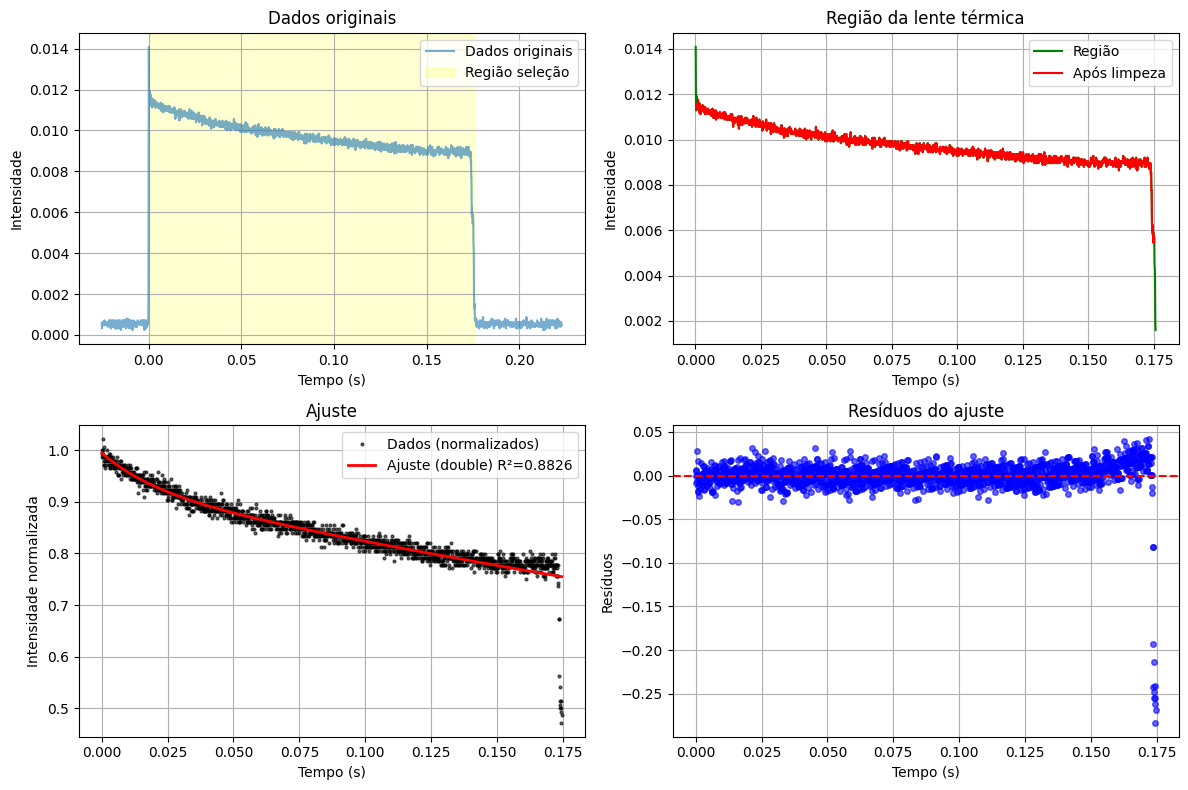

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

# -----------------------
# Leitura robusta do txt
# -----------------------
def read_oscilloscope_data(filename):
    data = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    for line in lines:
        s = line.strip()
        if not s:
            continue
        # tenta separar por tab, múltiplos espaços ou espaço simples
        if '\t' in s:
            parts = s.split('\t')
        else:
            parts = [p for p in s.split() if p]

        if len(parts) < 2:
            continue

        t_str = parts[0].replace(',', '.')
        y_str = parts[1].replace(',', '.')
        # remove caracteres estranhos
        t_str = re.sub(r'[^\d\.\-\+eE]', '', t_str)
        y_str = re.sub(r'[^\d\.\-\+eE]', '', y_str)
        if not t_str or not y_str:
            continue
        try:
            t = float(t_str)
            y = float(y_str)
            if np.isfinite(t) and np.isfinite(y):
                data.append([t, y])
        except:
            continue

    if len(data) == 0:
        raise ValueError("Nenhum dado válido lido do arquivo.")

    arr = np.array(data, dtype=float)
    return arr[:, 0], arr[:, 1]


# -----------------------
# Modelos
# -----------------------
def double_exp(t, y_inf, A, te, B, tc):
    """y_inf + A*exp(-t/te) + B*exp(-t/tc)"""
    return y_inf + A * np.exp(-t / te) + B * np.exp(-t / tc)

def single_exp(t, y_inf, A, te):
    return y_inf + A * np.exp(-t / te)


# -----------------------
# Encontrar região útil
# -----------------------
def find_thermal_lens_region(time, intensity, threshold_factor=0.7):
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    threshold = max_val * threshold_factor

    # início: primeiro índice acima do threshold
    start_idx = 0
    for i in range(len(intensity)):
        if intensity[i] >= threshold:
            start_idx = i
            break

    # fim: procura onde desceu perto do mínimo após o pico
    min_after = np.min(intensity[max_idx:])
    end_idx = len(intensity) - 1
    for i in range(max_idx, len(intensity)):
        if intensity[i] <= min_after + 0.1 * (max_val - min_after):
            end_idx = i
            break

    # garante janelas válidas
    if end_idx <= start_idx:
        start_idx = 0
        end_idx = len(intensity) - 1
    return start_idx, end_idx


# -----------------------
# Ajuste robusto
# -----------------------
def perform_fit(time, intensity_norm, debug=False):
    """
    Tenta ajustar modelo de dupla exponencial.
    Se falhar, recorre ao modelo simples (1 expo).
    Retorna popt, pcov, func_usada, r2
    """

    # zerar tempo (importante)
    time = np.asarray(time, dtype=float)
    time = time - time[0]

    # remover primeiros pontos que normalmente representam o pico/traniente (ajustável)
    skip_initial = max(5, int(0.01 * len(time)))  # pelo menos 5 pontos ou 1% dos dados
    t_fit = time[skip_initial:]
    y_fit = intensity_norm[skip_initial:]

    duration = max(t_fit.max() - t_fit.min(), 1e-6)

    # chutes iniciais inteligentes
    y_inf0 = np.mean(y_fit[-max(3, int(0.03 * len(y_fit))):])  # média dos últimos 3% (assíntota)
    A0 = float(max(1e-6, y_fit[0] - y_inf0))  # amplitude principal
    B0 = max(1e-6, 0.3 * A0)                 # segunda amplitude menor
    te0 = duration * 0.05
    tc0 = duration * 0.4

    # bounds para dupla exponencial
    lb = [0.0, 0.0, 1e-6, 0.0, 1e-6]
    ub = [2.0, 2.5, duration * 10.0 + 1.0, 2.5, duration * 10.0 + 1.0]

    p0 = [y_inf0, A0, te0, B0, tc0]

    if debug:
        print("DEBUG p0 double:", p0, "bounds lb/ub:", lb, ub)

    try:
        popt, pcov = curve_fit(
            double_exp, t_fit, y_fit, p0=p0, bounds=(lb, ub),
            maxfev=200000
        )
        y_pred = double_exp(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        if debug:
            print("Double-exp succeeded. R2:", r2)
        return popt, pcov, 'double', r2, (t_fit, y_fit)

    except Exception as e:
        if debug:
            print("Double-exp failed:", e)
            print("Tentando single-exp...")

        # fallback: single exponential
        p0_s = [y_inf0, A0, te0]
        lb_s = [0.0, 0.0, 1e-6]
        ub_s = [2.0, 3.0, duration * 10.0 + 1.0]
        try:
            popt, pcov = curve_fit(single_exp, t_fit, y_fit, p0=p0_s, bounds=(lb_s, ub_s), maxfev=200000)
            y_pred = single_exp(t_fit, *popt)
            ss_res = np.sum((y_fit - y_pred) ** 2)
            ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            return popt, pcov, 'single', r2, (t_fit, y_fit)
        except Exception as e2:
            raise RuntimeError("Ajuste falhou para ambos os modelos: " + str(e2))


# -----------------------
# Função principal
# -----------------------
def analyze_thermal_lens(filename, debug=False):
    print("=== ANALYSIS ===")
    time, intensity = read_oscilloscope_data(filename)
    print(f"Total pontos lidos: {len(time)}")

    # região presumida da lente térmica
    start_idx, end_idx = find_thermal_lens_region(time, intensity, threshold_factor=0.7)
    time_region = time[start_idx:end_idx + 1]
    intensity_region = intensity[start_idx:end_idx + 1]
    print(f"Região selecionada: {start_idx} -> {end_idx} ({len(time_region)} pontos)")

    # remove bordas (alguns pontos de transição)
    edge = 5
    if len(time_region) > 2 * edge:
        time_clean = time_region[edge:-edge]
        intensity_clean = intensity_region[edge:-edge]
    else:
        time_clean = time_region
        intensity_clean = intensity_region

    # normaliza usando primeiro ponto da região limpa
    intensity_norm = intensity_clean / intensity_clean[0]

    # rodar ajuste
    popt, pcov, model_used, r2, (t_fit, y_fit) = perform_fit(time_clean, intensity_norm, debug=debug)

    # interpretar parâmetros e erros
    if model_used == 'double':
        names = ['y_inf', 'A', 'te', 'B', 'tc']
    else:
        names = ['y_inf', 'A', 'te']

    perr = np.sqrt(np.abs(np.diag(pcov))) if pcov is not None else [np.nan] * len(popt)

    print("\n=== RESULTADOS DO AJUSTE ===")
    for n, v, e in zip(names, popt, perr):
        print(f"{n:6s} = {v:.6g} ± {e:.6g}")
    print(f"Modelo usado: {model_used}")
    print(f"R² = {r2:.6f}")

    # Preparar curvas para plot
    # usamos tempo zerado consistentemente para exibição
    t_zeroed = time_clean - time_clean[0]
    t_plot = np.linspace(t_zeroed.min(), t_zeroed.max(), 1000)
    if model_used == 'double':
        y_plot = double_exp(t_plot, *popt)
        y_fit_model = double_exp(t_zeroed - 0.0, *popt)
    else:
        y_plot = single_exp(t_plot, *popt)
        y_fit_model = single_exp(t_zeroed - 0.0, *popt)

    # Plot
    plt.figure(figsize=(12, 8))
    # 1) dados originais
    plt.subplot(2, 2, 1)
    plt.plot(time, intensity, '-', alpha=0.6, label='Dados originais')
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.18, color='yellow', label='Região seleção')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade'); plt.title('Dados originais')
    plt.legend(); plt.grid(True)

    # 2) região selecionada e limpa
    plt.subplot(2, 2, 2)
    plt.plot(time_region, intensity_region, 'g-', label='Região')
    plt.plot(time_clean, intensity_clean, 'r-', label='Após limpeza')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade'); plt.title('Região da lente térmica')
    plt.legend(); plt.grid(True)

    # 3) ajuste sobre dados normalizados
    plt.subplot(2, 2, 3)
    plt.plot(t_zeroed, intensity_norm, 'k.', markersize=4, alpha=0.6, label='Dados (normalizados)')
    plt.plot(t_plot, y_plot, 'r-', linewidth=2, label=f'Ajuste ({model_used}) R²={r2:.4f}')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade normalizada'); plt.title('Ajuste')
    plt.legend(); plt.grid(True)

    # 4) resíduos
    plt.subplot(2, 2, 4)
    residuals = intensity_norm - y_fit_model
    plt.plot(t_zeroed, residuals, 'bo', markersize=4, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Tempo (s)'); plt.ylabel('Resíduos'); plt.title('Resíduos do ajuste')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return {
        'model': model_used,
        'params': dict(zip(names, popt)),
        'errors': dict(zip(names, perr)),
        'r2': r2,
        'time_zeroed': t_zeroed,
        'intensity_norm': intensity_norm,
        'fitted_curve': y_fit_model
    }


# -----------------------
# Execução direta
# -----------------------
if __name__ == "__main__":
    fname = "dados_osciloscopio55.txt"   # altere se necessário
    results = analyze_thermal_lens(fname, debug=True)


=== ANALYSIS ===
Total pontos lidos: 2483
[find_region] n=2483, initial_points=75
[find_region] baseline mean=1.94155, std=0.000309999
[find_region] d/dt mean=-0.152381, std=0.328537
[find_region] threshold_d_dt=1.81884, intensity_threshold=0.000929998
[find_region] subida detectada em i=381, t=-0.0002, dI/dt=46.8572, dI=0.00145067
[find_region] retorno start_idx=381 end_idx=2042 (t_start=-0.0002, t_end=0.1659)
Região selecionada: indices 381 -> 2042 (1662 pontos)
perform_fit: p0= [np.float64(0.9916304996024383), 0.008268039358600654, np.float64(0.008175), 0.002480411807580196, np.float64(0.0654)] bounds= [0.0, 0.0, 1e-06, 0.0, 1e-06] [2.0, 2.5, np.float64(2.635), 2.5, np.float64(2.635)]

=== RESULTADOS DO AJUSTE ===
y_inf  = 0.991066 ± 0.000135996
A      = 1.88413e-08 ± 0.0827973
te     = 0.0643186 ± 2345.04
B      = 0.00936546 ± 0.0826418
tc     = 0.05963 ± 0.0379395
Modelo usado: double
R² = 0.984441


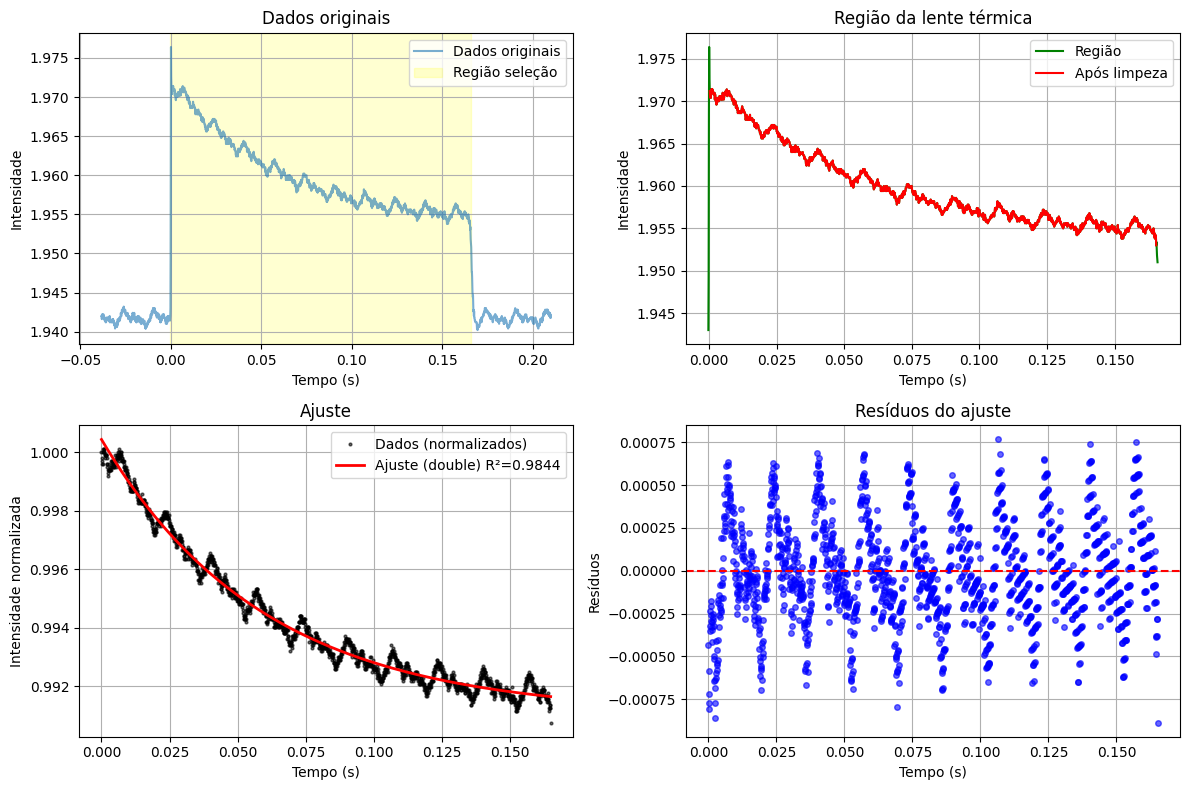

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

# -----------------------
# Leitura robusta do txt
# -----------------------
def read_oscilloscope_data(filename):
    data = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    for line in lines:
        s = line.strip()
        if not s:
            continue
        if '\t' in s:
            parts = s.split('\t')
        else:
            parts = [p for p in s.split() if p]

        if len(parts) < 2:
            continue

        t_str = parts[0].replace(',', '.')
        y_str = parts[1].replace(',', '.')
        t_str = re.sub(r'[^\d\.\-\+eE]', '', t_str)
        y_str = re.sub(r'[^\d\.\-\+eE]', '', y_str)
        if not t_str or not y_str:
            continue
        try:
            t = float(t_str)
            y = float(y_str)
            if np.isfinite(t) and np.isfinite(y):
                data.append([t, y])
        except:
            continue

    if len(data) == 0:
        raise ValueError("Nenhum dado válido lido do arquivo.")

    arr = np.array(data, dtype=float)
    return arr[:, 0], arr[:, 1]


# -----------------------
# Modelos
# -----------------------
def double_exp(t, y_inf, A, te, B, tc):
    return y_inf + A * np.exp(-t / te) + B * np.exp(-t / tc)

def single_exp(t, y_inf, A, te):
    return y_inf + A * np.exp(-t / te)


# -----------------------
# Nova função: primeira subida significativa (derivada)
# -----------------------
def find_thermal_lens_region(time, intensity,
                             initial_frac=0.03,
                             min_initial_points=10,
                             deriv_smooth_window=7,
                             threshold_multiplier=6.0,
                             min_rise_frac=0.01,
                             fallback_threshold_factor=0.85,
                             debug=False):
    """
    Detecta inicio/fim da região de lente térmica usando:
      - estimativa do ruído inicial (primeiros pontos)
      - derivada dI/dt suavizada
      - procura pela primeira posição onde derivada > limiar adaptativo
        e o aumento de intensidade é significativo

    Parâmetros ajustáveis:
      initial_frac: fração inicial do sinal para estimar ruído (ex: 0.03 = 3%)
      min_initial_points: mínimo de pontos para a janela inicial
      deriv_smooth_window: janela (n pontos) para suavizar derivada (use ímpar)
      threshold_multiplier: multiplicador do desvio padrão do ruído para estabelecer limiar
      min_rise_frac: fração do pico inicial (max-baseline) que considera subida significativa
      fallback_threshold_factor: se método principal falhar, usa o método clássico por percentil do máximo
    """
    time = np.asarray(time, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    n = len(time)
    if n < 10:
        return 0, n - 1

    # janela inicial (para estimar baseline/ruído)
    initial_points = max(min_initial_points, int(np.ceil(initial_frac * n)))
    initial_points = min(initial_points, n // 4)  # não tomar mais que 1/4 dos dados
    if debug:
        print(f"[find_region] n={n}, initial_points={initial_points}")

    baseline_vals = intensity[:initial_points]
    baseline_mean = np.mean(baseline_vals)
    baseline_std = np.std(baseline_vals)
    if debug:
        print(f"[find_region] baseline mean={baseline_mean:.6g}, std={baseline_std:.6g}")

    # derivada (leva em conta espaçamento irregular de tempo)
    dI_dt = np.gradient(intensity, time)
    # suaviza derivada com média móvel
    k = int(deriv_smooth_window)
    if k < 1:
        k = 1
    if k % 2 == 0:
        k += 1
    if k > 1:
        kernel = np.ones(k) / k
        dI_dt_smooth = np.convolve(dI_dt, kernel, mode='same')
    else:
        dI_dt_smooth = dI_dt

    # estatísticas da derivada no baseline
    baseline_d_dt = dI_dt_smooth[:initial_points]
    ddt_mean = np.mean(baseline_d_dt)
    ddt_std = np.std(baseline_d_dt)
    if debug:
        print(f"[find_region] d/dt mean={ddt_mean:.6g}, std={ddt_std:.6g}")

    # limiar adaptativo para detectar subida
    threshold_d_dt = ddt_mean + threshold_multiplier * max(ddt_std, 1e-12)
    # limiar absoluto de aumento de intensidade (evita disparos por ruído mesmo que derivada alta)
    peak_val = np.max(intensity)
    intensity_threshold = max(3 * baseline_std, min_rise_frac * (peak_val - baseline_mean), 1e-12)

    if debug:
        print(f"[find_region] threshold_d_dt={threshold_d_dt:.6g}, intensity_threshold={intensity_threshold:.6g}")

    # procura primeira posição onde derivada > threshold e aumento de intensidade significativo
    start_idx = None
    for i in range(initial_points, n):
        if dI_dt_smooth[i] > threshold_d_dt and (intensity[i] - baseline_mean) > intensity_threshold:
            start_idx = i
            if debug:
                print(f"[find_region] subida detectada em i={i}, t={time[i]:.6g}, dI/dt={dI_dt_smooth[i]:.6g}, dI={intensity[i]-baseline_mean:.6g}")
            break

    # fallback: se não encontrou, usa critério clássico por fração do máximo, mas garantindo não escolher índices muito iniciais
    if start_idx is None:
        if debug:
            print("[find_region] critério por derivada falhou -> fallback por threshold do máximo")
        max_idx = np.argmax(intensity)
        threshold_val = peak_val * fallback_threshold_factor
        for i in range(max(0, initial_points), n):
            if intensity[i] >= threshold_val:
                start_idx = i
                break

    # se ainda não encontrou, simplesmente usa início do sinal (0)
    if start_idx is None:
        start_idx = 0
        if debug:
            print("[find_region] fallback final -> start_idx = 0")

    # encontrar fim: procura depois do pico quando descreve até próximo platô/min próximo
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    min_after_peak = np.min(intensity[max_idx:]) if max_idx < n - 1 else intensity[-1]
    end_idx = n - 1
    for i in range(max_idx, n):
        if intensity[i] <= min_after_peak + 0.3 * (max_val - min_after_peak):
            end_idx = i
            break

    # garante que start < end e start não seja extremamente inicial (se for, limita a initial_points)
    start_idx = int(min(max(start_idx, 0), n - 1))
    end_idx = int(min(max(end_idx, 0), n - 1))
    if start_idx >= end_idx:
        start_idx = max(0, min(initial_points, n - 2))
        end_idx = n - 1

    if debug:
        print(f"[find_region] retorno start_idx={start_idx} end_idx={end_idx} (t_start={time[start_idx]:.6g}, t_end={time[end_idx]:.6g})")

    return start_idx, end_idx


# -----------------------
# Ajuste robusto (mesma lógica anterior)
# -----------------------
def perform_fit(time, intensity_norm, debug=False):
    time = np.asarray(time, dtype=float)
    time = time - time[0]
    skip_initial = max(5, int(0.01 * len(time)))
    t_fit = time[skip_initial:]
    y_fit = intensity_norm[skip_initial:]
    duration = max(t_fit.max() - t_fit.min(), 1e-6)

    # chutes
    y_inf0 = np.mean(y_fit[-max(3, int(0.03 * len(y_fit))):])
    A0 = float(max(1e-6, y_fit[0] - y_inf0))
    B0 = max(1e-6, 0.3 * A0)
    te0 = duration * 0.05
    tc0 = duration * 0.4

    p0 = [y_inf0, A0, te0, B0, tc0]
    lb = [0.0, 0.0, 1e-6, 0.0, 1e-6]
    ub = [2.0, 2.5, duration * 10.0 + 1.0, 2.5, duration * 10.0 + 1.0]

    if debug:
        print("perform_fit: p0=", p0, "bounds=", lb, ub)

    try:
        popt, pcov = curve_fit(
            double_exp, t_fit, y_fit, p0=p0, bounds=(lb, ub),
            maxfev=200000
        )
        y_pred = double_exp(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return popt, pcov, 'double', r2, (t_fit, y_fit)
    except Exception as e:
        if debug:
            print("perform_fit: double-exp failed:", e)
        # fallback single
        p0_s = [y_inf0, A0, te0]
        lb_s = [0.0, 0.0, 1e-6]
        ub_s = [2.0, 3.0, duration * 10.0 + 1.0]
        try:
            popt, pcov = curve_fit(single_exp, t_fit, y_fit, p0=p0_s, bounds=(lb_s, ub_s), maxfev=200000)
            y_pred = single_exp(t_fit, *popt)
            ss_res = np.sum((y_fit - y_pred) ** 2)
            ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            return popt, pcov, 'single', r2, (t_fit, y_fit)
        except Exception as e2:
            raise RuntimeError("Ajuste falhou para ambos os modelos: " + str(e2))


# -----------------------
# Função principal
# -----------------------
def analyze_thermal_lens(filename, debug=False):
    print("=== ANALYSIS ===")
    time, intensity = read_oscilloscope_data(filename)
    print(f"Total pontos lidos: {len(time)}")

    # detectar região com o novo critério
    start_idx, end_idx = find_thermal_lens_region(time, intensity,
                                                 initial_frac=0.03,
                                                 min_initial_points=10,
                                                 deriv_smooth_window=7,
                                                 threshold_multiplier=6.0,
                                                 min_rise_frac=0.01,
                                                 fallback_threshold_factor=0.85,
                                                 debug=debug)
    time_region = time[start_idx:end_idx + 1]
    intensity_region = intensity[start_idx:end_idx + 1]
    print(f"Região selecionada: indices {start_idx} -> {end_idx} ({len(time_region)} pontos)")

    # remove bordas
    edge = 5
    if len(time_region) > 2 * edge:
        time_clean = time_region[edge:-edge]
        intensity_clean = intensity_region[edge:-edge]
    else:
        time_clean = time_region
        intensity_clean = intensity_region

    # normaliza (cuidando de dividir por zero)
    eps = 1e-15
    intensity_clean = np.asarray(intensity_clean, dtype=float)
    if abs(intensity_clean[0]) < eps:
        intensity_clean[0] += eps
    intensity_norm = intensity_clean / intensity_clean[0]

    # ajuste
    popt, pcov, model_used, r2, (t_fit, y_fit) = perform_fit(time_clean, intensity_norm, debug=debug)

    if model_used == 'double':
        names = ['y_inf', 'A', 'te', 'B', 'tc']
    else:
        names = ['y_inf', 'A', 'te']

    perr = np.sqrt(np.abs(np.diag(pcov))) if pcov is not None else [np.nan] * len(popt)

    print("\n=== RESULTADOS DO AJUSTE ===")
    for n, v, e in zip(names, popt, perr):
        print(f"{n:6s} = {v:.6g} ± {e:.6g}")
    print(f"Modelo usado: {model_used}")
    print(f"R² = {r2:.6f}")

    # plot
    t_zeroed = time_clean - time_clean[0]
    t_plot = np.linspace(t_zeroed.min(), t_zeroed.max(), 1000)
    if model_used == 'double':
        y_plot = double_exp(t_plot, *popt)
        y_fit_model = double_exp(t_zeroed, *popt)
    else:
        y_plot = single_exp(t_plot, *popt)
        y_fit_model = single_exp(t_zeroed, *popt)

    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1)
    plt.plot(time, intensity, '-', alpha=0.6, label='Dados originais')
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.18, color='yellow', label='Região seleção')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade'); plt.title('Dados originais')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(time_region, intensity_region, 'g-', label='Região')
    plt.plot(time_clean, intensity_clean, 'r-', label='Após limpeza')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade'); plt.title('Região da lente térmica')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(t_zeroed, intensity_norm, 'k.', markersize=4, alpha=0.6, label='Dados (normalizados)')
    plt.plot(t_plot, y_plot, 'r-', linewidth=2, label=f'Ajuste ({model_used}) R²={r2:.4f}')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade normalizada'); plt.title('Ajuste')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 2, 4)
    residuals = intensity_norm - y_fit_model
    plt.plot(t_zeroed, residuals, 'bo', markersize=4, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Tempo (s)'); plt.ylabel('Resíduos'); plt.title('Resíduos do ajuste')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return {
        'model': model_used,
        'params': dict(zip(names, popt)),
        'errors': dict(zip(names, perr)),
        'r2': r2,
        'time_zeroed': t_zeroed,
        'intensity_norm': intensity_norm,
        'fitted_curve': y_fit_model
    }


# -----------------------
# Execução direta
# -----------------------
if __name__ == "__main__":
    fname = "1010 novo.txt"   # altere conforme necessário
    results = analyze_thermal_lens(fname, debug=True)


=== ANALYSIS ===
Total pontos lidos: 2483
[find_region] n=2483, initial_points=75
[find_region] baseline mean=1.94155, std=0.000309999
[find_region] d/dt mean=-0.152381, std=0.328537
[find_region] threshold_d_dt=1.81884, intensity_threshold=0.000929998
[find_region] subida detectada em i=381, t=-0.0002, dI/dt=46.8572, dI=0.00145067
[find_region] retorno start_idx=381 end_idx=2042 (t_start=-0.0002, t_end=0.1659)
Região selecionada: indices 381 -> 2042 (1662 pontos)
perform_fit: p0= [np.float64(0.9916304996024383), 0.008268039358600654, np.float64(0.008175), 0.002480411807580196, np.float64(0.0654)] bounds= [0.0, 0.0, 1e-06, 0.0, 1e-06] [2.0, 2.5, np.float64(2.635), 2.5, np.float64(2.635)]

=== RESULTADOS DO AJUSTE ===
y_inf  = 0.991066 ± 0.000135996
A      = 1.88413e-08 ± 0.0827973
te     = 0.0643186 ± 2345.04
B      = 0.00936546 ± 0.0826418
tc     = 0.05963 ± 0.0379395
Modelo usado: double
R² = 0.984441


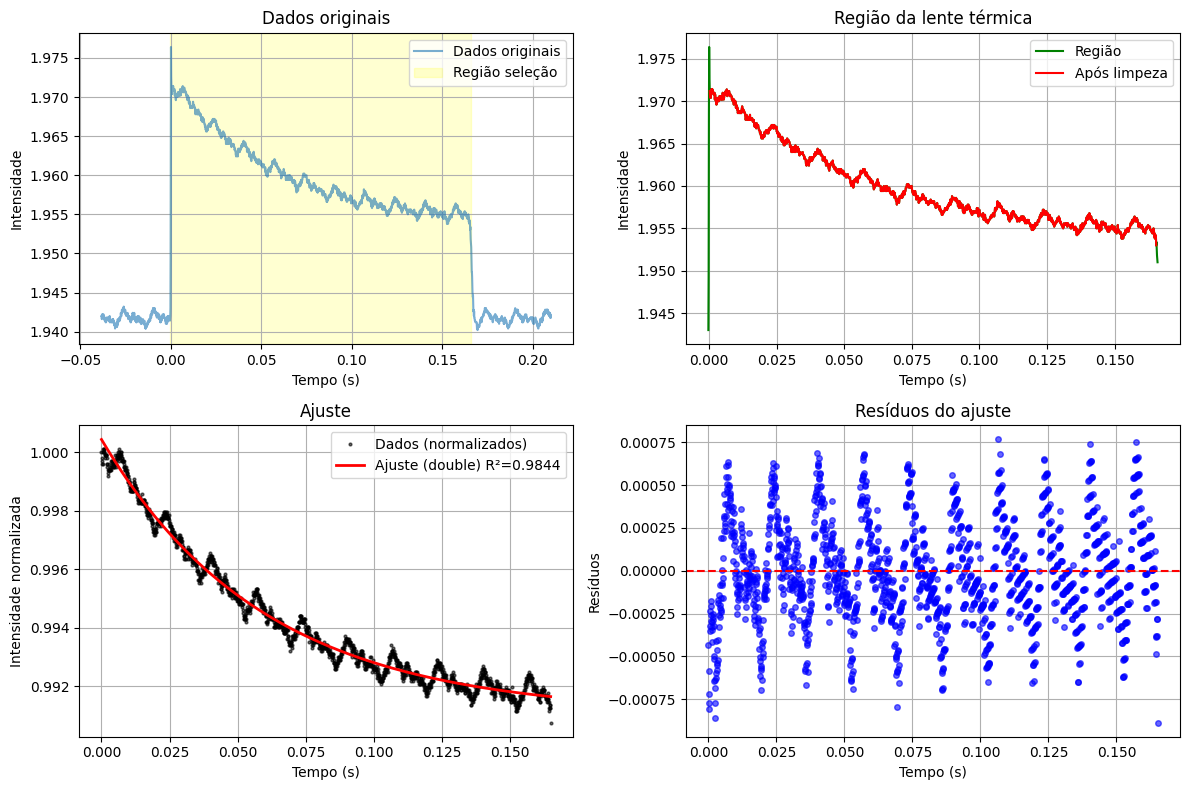

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

# -----------------------
# Leitura robusta do txt
# -----------------------
def read_oscilloscope_data(filename):
    data = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    for line in lines:
        s = line.strip()
        if not s:
            continue
        if '\t' in s:
            parts = s.split('\t')
        else:
            parts = [p for p in s.split() if p]

        if len(parts) < 2:
            continue

        t_str = parts[0].replace(',', '.')
        y_str = parts[1].replace(',', '.')
        t_str = re.sub(r'[^\d\.\-\+eE]', '', t_str)
        y_str = re.sub(r'[^\d\.\-\+eE]', '', y_str)
        if not t_str or not y_str:
            continue
        try:
            t = float(t_str)
            y = float(y_str)
            if np.isfinite(t) and np.isfinite(y):
                data.append([t, y])
        except:
            continue

    if len(data) == 0:
        raise ValueError("Nenhum dado válido lido do arquivo.")

    arr = np.array(data, dtype=float)
    return arr[:, 0], arr[:, 1]


# -----------------------
# Modelos
# -----------------------
def double_exp(t, y_inf, A, te, B, tc):
    return y_inf + A * np.exp(-t / te) + B * np.exp(-t / tc)

def single_exp(t, y_inf, A, te):
    return y_inf + A * np.exp(-t / te)


# -----------------------
# Nova função: primeira subida significativa (derivada)
# -----------------------
def find_thermal_lens_region(time, intensity,
                             initial_frac=0.03,
                             min_initial_points=10,
                             deriv_smooth_window=7,
                             threshold_multiplier=6.0,
                             min_rise_frac=0.01,
                             fallback_threshold_factor=0.85,
                             debug=False):
    """
    Detecta inicio/fim da região de lente térmica usando:
      - estimativa do ruído inicial (primeiros pontos)
      - derivada dI/dt suavizada
      - procura pela primeira posição onde derivada > limiar adaptativo
        e o aumento de intensidade é significativo

    Parâmetros ajustáveis:
      initial_frac: fração inicial do sinal para estimar ruído (ex: 0.03 = 3%)
      min_initial_points: mínimo de pontos para a janela inicial
      deriv_smooth_window: janela (n pontos) para suavizar derivada (use ímpar)
      threshold_multiplier: multiplicador do desvio padrão do ruído para estabelecer limiar
      min_rise_frac: fração do pico inicial (max-baseline) que considera subida significativa
      fallback_threshold_factor: se método principal falhar, usa o método clássico por percentil do máximo
    """
    time = np.asarray(time, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    n = len(time)
    if n < 10:
        return 0, n - 1

    # janela inicial (para estimar baseline/ruído)
    initial_points = max(min_initial_points, int(np.ceil(initial_frac * n)))
    initial_points = min(initial_points, n // 4)  # não tomar mais que 1/4 dos dados
    if debug:
        print(f"[find_region] n={n}, initial_points={initial_points}")

    baseline_vals = intensity[:initial_points]
    baseline_mean = np.mean(baseline_vals)
    baseline_std = np.std(baseline_vals)
    if debug:
        print(f"[find_region] baseline mean={baseline_mean:.6g}, std={baseline_std:.6g}")

    # derivada (leva em conta espaçamento irregular de tempo)
    dI_dt = np.gradient(intensity, time)
    # suaviza derivada com média móvel
    k = int(deriv_smooth_window)
    if k < 1:
        k = 1
    if k % 2 == 0:
        k += 1
    if k > 1:
        kernel = np.ones(k) / k
        dI_dt_smooth = np.convolve(dI_dt, kernel, mode='same')
    else:
        dI_dt_smooth = dI_dt

    # estatísticas da derivada no baseline
    baseline_d_dt = dI_dt_smooth[:initial_points]
    ddt_mean = np.mean(baseline_d_dt)
    ddt_std = np.std(baseline_d_dt)
    if debug:
        print(f"[find_region] d/dt mean={ddt_mean:.6g}, std={ddt_std:.6g}")

    # limiar adaptativo para detectar subida
    threshold_d_dt = ddt_mean + threshold_multiplier * max(ddt_std, 1e-12)
    # limiar absoluto de aumento de intensidade (evita disparos por ruído mesmo que derivada alta)
    peak_val = np.max(intensity)
    intensity_threshold = max(3 * baseline_std, min_rise_frac * (peak_val - baseline_mean), 1e-12)

    if debug:
        print(f"[find_region] threshold_d_dt={threshold_d_dt:.6g}, intensity_threshold={intensity_threshold:.6g}")

    # procura primeira posição onde derivada > threshold e aumento de intensidade significativo
    start_idx = None
    for i in range(initial_points, n):
        if dI_dt_smooth[i] > threshold_d_dt and (intensity[i] - baseline_mean) > intensity_threshold:
            start_idx = i
            if debug:
                print(f"[find_region] subida detectada em i={i}, t={time[i]:.6g}, dI/dt={dI_dt_smooth[i]:.6g}, dI={intensity[i]-baseline_mean:.6g}")
            break

    # fallback: se não encontrou, usa critério clássico por fração do máximo, mas garantindo não escolher índices muito iniciais
    if start_idx is None:
        if debug:
            print("[find_region] critério por derivada falhou -> fallback por threshold do máximo")
        max_idx = np.argmax(intensity)
        threshold_val = peak_val * fallback_threshold_factor
        for i in range(max(0, initial_points), n):
            if intensity[i] >= threshold_val:
                start_idx = i
                break

    # se ainda não encontrou, simplesmente usa início do sinal (0)
    if start_idx is None:
        start_idx = 0
        if debug:
            print("[find_region] fallback final -> start_idx = 0")

    # encontrar fim: procura depois do pico quando descreve até próximo platô/min próximo
    max_idx = np.argmax(intensity)
    max_val = intensity[max_idx]
    min_after_peak = np.min(intensity[max_idx:]) if max_idx < n - 1 else intensity[-1]
    end_idx = n - 1
    for i in range(max_idx, n):
        if intensity[i] <= min_after_peak + 0.3 * (max_val - min_after_peak):
            end_idx = i
            break

    # garante que start < end e start não seja extremamente inicial (se for, limita a initial_points)
    start_idx = int(min(max(start_idx, 0), n - 1))
    end_idx = int(min(max(end_idx, 0), n - 1))
    if start_idx >= end_idx:
        start_idx = max(0, min(initial_points, n - 2))
        end_idx = n - 1

    if debug:
        print(f"[find_region] retorno start_idx={start_idx} end_idx={end_idx} (t_start={time[start_idx]:.6g}, t_end={time[end_idx]:.6g})")

    return start_idx, end_idx


# -----------------------
# Ajuste robusto (mesma lógica anterior)
# -----------------------
def perform_fit(time, intensity_norm, debug=False):
    time = np.asarray(time, dtype=float)
    time = time - time[0]
    skip_initial = max(5, int(0.01 * len(time)))
    t_fit = time[skip_initial:]
    y_fit = intensity_norm[skip_initial:]
    duration = max(t_fit.max() - t_fit.min(), 1e-6)

    # chutes
    y_inf0 = np.mean(y_fit[-max(3, int(0.03 * len(y_fit))):])
    A0 = float(max(1e-6, y_fit[0] - y_inf0))
    B0 = max(1e-6, 0.3 * A0)
    te0 = duration * 0.05
    tc0 = duration * 0.4

    p0 = [y_inf0, A0, te0, B0, tc0]
    lb = [0.0, 0.0, 1e-6, 0.0, 1e-6]
    ub = [2.0, 2.5, duration * 10.0 + 1.0, 2.5, duration * 10.0 + 1.0]

    if debug:
        print("perform_fit: p0=", p0, "bounds=", lb, ub)

    try:
        popt, pcov = curve_fit(
            double_exp, t_fit, y_fit, p0=p0, bounds=(lb, ub),
            maxfev=200000
        )
        y_pred = double_exp(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred) ** 2)
        ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return popt, pcov, 'double', r2, (t_fit, y_fit)
    except Exception as e:
        if debug:
            print("perform_fit: double-exp failed:", e)
        # fallback single
        p0_s = [y_inf0, A0, te0]
        lb_s = [0.0, 0.0, 1e-6]
        ub_s = [2.0, 3.0, duration * 10.0 + 1.0]
        try:
            popt, pcov = curve_fit(single_exp, t_fit, y_fit, p0=p0_s, bounds=(lb_s, ub_s), maxfev=200000)
            y_pred = single_exp(t_fit, *popt)
            ss_res = np.sum((y_fit - y_pred) ** 2)
            ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            return popt, pcov, 'single', r2, (t_fit, y_fit)
        except Exception as e2:
            raise RuntimeError("Ajuste falhou para ambos os modelos: " + str(e2))


# -----------------------
# Função principal
# -----------------------
def analyze_thermal_lens(filename, debug=False):
    print("=== ANALYSIS ===")
    time, intensity = read_oscilloscope_data(filename)
    print(f"Total pontos lidos: {len(time)}")

    # detectar região com o novo critério
    start_idx, end_idx = find_thermal_lens_region(time, intensity,
                                                 initial_frac=0.03,
                                                 min_initial_points=10,
                                                 deriv_smooth_window=7,
                                                 threshold_multiplier=6.0,
                                                 min_rise_frac=0.01,
                                                 fallback_threshold_factor=0.85,
                                                 debug=debug)
    time_region = time[start_idx:end_idx + 1]
    intensity_region = intensity[start_idx:end_idx + 1]
    print(f"Região selecionada: indices {start_idx} -> {end_idx} ({len(time_region)} pontos)")

    # remove bordas
    edge = 5
    if len(time_region) > 2 * edge:
        time_clean = time_region[edge:-edge]
        intensity_clean = intensity_region[edge:-edge]
    else:
        time_clean = time_region
        intensity_clean = intensity_region

    # normaliza (cuidando de dividir por zero)
    eps = 1e-15
    intensity_clean = np.asarray(intensity_clean, dtype=float)
    if abs(intensity_clean[0]) < eps:
        intensity_clean[0] += eps
    intensity_norm = intensity_clean / intensity_clean[0]

    # ajuste
    popt, pcov, model_used, r2, (t_fit, y_fit) = perform_fit(time_clean, intensity_norm, debug=debug)

    if model_used == 'double':
        names = ['y_inf', 'A', 'te', 'B', 'tc']
    else:
        names = ['y_inf', 'A', 'te']

    perr = np.sqrt(np.abs(np.diag(pcov))) if pcov is not None else [np.nan] * len(popt)

    print("\n=== RESULTADOS DO AJUSTE ===")
    for n, v, e in zip(names, popt, perr):
        print(f"{n:6s} = {v:.6g} ± {e:.6g}")
    print(f"Modelo usado: {model_used}")
    print(f"R² = {r2:.6f}")

    # plot
    t_zeroed = time_clean - time_clean[0]
    t_plot = np.linspace(t_zeroed.min(), t_zeroed.max(), 1000)
    if model_used == 'double':
        y_plot = double_exp(t_plot, *popt)
        y_fit_model = double_exp(t_zeroed, *popt)
    else:
        y_plot = single_exp(t_plot, *popt)
        y_fit_model = single_exp(t_zeroed, *popt)

    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1)
    plt.plot(time, intensity, '-', alpha=0.6, label='Dados originais')
    plt.axvspan(time[start_idx], time[end_idx], alpha=0.18, color='yellow', label='Região seleção')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade'); plt.title('Dados originais')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(time_region, intensity_region, 'g-', label='Região')
    plt.plot(time_clean, intensity_clean, 'r-', label='Após limpeza')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade'); plt.title('Região da lente térmica')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(t_zeroed, intensity_norm, 'k.', markersize=4, alpha=0.6, label='Dados (normalizados)')
    plt.plot(t_plot, y_plot, 'r-', linewidth=2, label=f'Ajuste ({model_used}) R²={r2:.4f}')
    plt.xlabel('Tempo (s)'); plt.ylabel('Intensidade normalizada'); plt.title('Ajuste')
    plt.legend(); plt.grid(True)

    plt.subplot(2, 2, 4)
    residuals = intensity_norm - y_fit_model
    plt.plot(t_zeroed, residuals, 'bo', markersize=4, alpha=0.6)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Tempo (s)'); plt.ylabel('Resíduos'); plt.title('Resíduos do ajuste')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return {
        'model': model_used,
        'params': dict(zip(names, popt)),
        'errors': dict(zip(names, perr)),
        'r2': r2,
        'time_zeroed': t_zeroed,
        'intensity_norm': intensity_norm,
        'fitted_curve': y_fit_model
    }


# -----------------------
# Execução direta
# -----------------------
if __name__ == "__main__":
    fname = "1010novo.txt"   # altere conforme necessário
    results = analyze_thermal_lens(fname, debug=True)

### Código com o Ajuste não linear igual o origin:

=== ANÁLISE DE LENTE TÉRMICA ===

1. Lendo dados do osciloscópio...
   Dados carregados: 2483 pontos
2. Separando região de interesse...
   Região selecionada: 1664 pontos (índices 384 a 2048)
3. Removendo pontos das extremidades...
   Pontos restantes: 1654
4. Normalizando intensidade...
5. Estimando parâmetros iniciais...
Debug: estimar_parametros_iniciais received tempo shape: (1654,), intensity_norm shape: (1654,)
   Io inicial: 1.00000
   te inicial: 8.26500e-03
   tc inicial: 5.15000e-02
   m inicial: 1.00000
6. Realizando ajuste não linear (200 iterações)...

=== RESULTADOS FINAIS ===


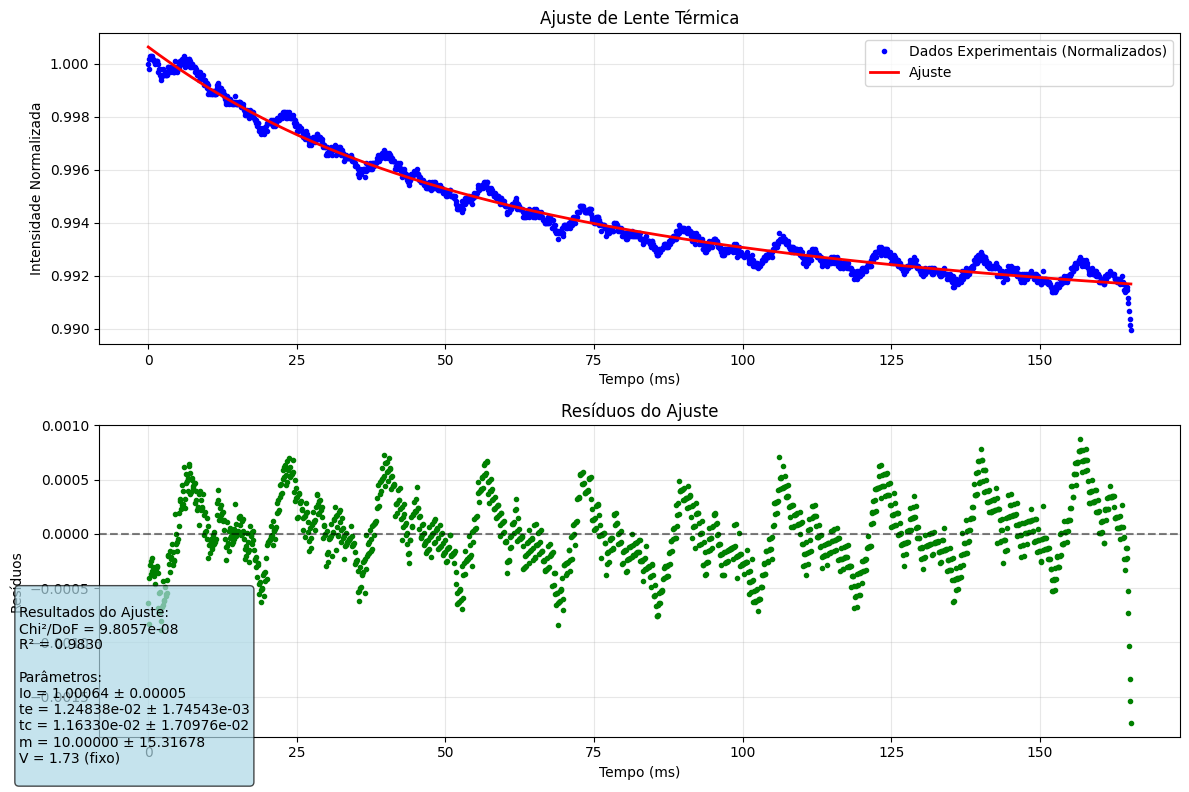


Resultados do Ajuste:
Chi²/DoF = 9.8057e-08
R² = 0.9830

Parâmetros:
Io = 1.00064 ± 0.00005
te = 1.24838e-02 ± 1.74543e-03
tc = 1.16330e-02 ± 1.70976e-02
m = 10.00000 ± 15.31678
V = 1.73 (fixo)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re

# ============================================================
# Função robusta de leitura
# ============================================================
def ler_dados_osciloscopio(filename):
    """
    Lê os dados do osciloscópio em formato txt usando um método robusto.
    """
    data = []
    try:
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()

        for line in lines:
            s = line.strip()
            if not s:
                continue
            if '\t' in s:
                parts = s.split('\t')
            else:
                parts = [p for p in s.split() if p]

            if len(parts) < 2:
                continue

            t_str = parts[0].replace(',', '.')
            y_str = parts[1].replace(',', '.')
            t_str = re.sub(r'[^\d\.\-\+eE]', '', t_str)
            y_str = re.sub(r'[^\d\.\-\+eE]', '', y_str)

            if not t_str or not y_str:
                continue

            try:
                t = float(t_str)
                y = float(y_str)
                if np.isfinite(t) and np.isfinite(y):
                    data.append([t, y])
            except ValueError:
                continue
            except Exception as e:
                # print(f"Warning: Error processing line: {line.strip()} - {e}")
                continue


        if len(data) == 0:
            print("Nenhum dado válido lido do arquivo após processamento linha a linha.")
            return None, None

        arr = np.array(data, dtype=float)
        return arr[:, 0], arr[:, 1]

    except FileNotFoundError:
        print(f"Arquivo {filename} não encontrado!")
        return None, None
    except Exception as e:
        print(f"Erro geral ao ler ou processar arquivo: {e}")
        return None, None


def separar_regiao_interesse(tempo, intensidade, threshold_factor=0.1):
    """
    Separa a região de interesse onde ocorre a lente térmica
    Identifica o pico e a região de decaimento
    """
    tempo = np.asarray(tempo, dtype=float)
    intensidade = np.asarray(intensidade, dtype=float)

    if len(tempo) == 0 or len(intensidade) == 0:
         print("Dados vazios passados para separar_regiao_interesse.")
         return np.array([]), np.array([]), 0, 0


    max_idx = np.argmax(intensidade)
    max_intensity = intensidade[max_idx]
    min_intensity = np.min(intensidade)
    threshold = min_intensity + threshold_factor * (max_intensity - min_intensity)

    start_idx = 0
    for i in range(max_idx, -1, -1):
        if intensidade[i] < threshold:
            start_idx = i + 1
            break
    start_idx = min(start_idx + 5, max_idx)

    end_idx = len(intensidade) - 1
    for i in range(max_idx, len(intensidade)):
        if intensidade[i] < threshold:
            end_idx = i - 1
            break
    end_idx = max(end_idx - 5, max_idx)

    start_idx = max(0, start_idx)
    end_idx = min(len(intensidade) - 1, end_idx)

    min_points_for_fit = 30
    if start_idx >= end_idx or (end_idx - start_idx + 1) < min_points_for_fit:
        print(f"Warning: Automatic region selection failed or resulted in a small region ({end_idx-start_idx+1} points). Using fallback.")
        if max_idx < len(intensidade) - 1:
            start_idx = max_idx
            end_idx = min(len(intensidade) - 1, start_idx + min_points_for_fit - 1)
            if (end_idx - start_idx + 1) < min_points_for_fit:
                 start_idx = max(0, len(intensidade) - min_points_for_fit)
                 end_idx = len(intensidade) - 1
        else:
            start_idx = max(0, len(intensidade) - min_points_for_fit)
            end_idx = len(intensidade) - 1

        if start_idx >= end_idx or (end_idx - start_idx + 1) < min_points_for_fit:
             print(f"Error: Fallback region selection failed to find a valid region with at least {min_points_for_fit} points.")
             return np.array([]), np.array([]), 0, 0

    return tempo[start_idx:end_idx], intensidade[start_idx:end_idx], start_idx, end_idx

def remover_pontos_extremidade(tempo, intensidade, pontos_remover=5):
    """
    Remove alguns pontos das extremidades para melhorar o ajuste
    """
    if len(tempo) <= 2 * pontos_remover:
        pontos_remover = len(tempo) // 20
        if pontos_remover < 1:
             return tempo, intensidade

    return tempo[pontos_remover:-pontos_remover], intensidade[pontos_remover:-pontos_remover]

def normalizar_intensidade(intensidade):
    """
    Normaliza a intensidade usando o primeiro ponto como referência
    Handles potential division by zero
    """
    if len(intensidade) == 0:
        print("Warning: Attempted to normalize empty intensity array.")
        return np.array([])

    first_point = intensidade[0]
    if abs(first_point) < 1e-9:
        print("Warning: First intensity point is close to zero. Normalization might be unstable.")
        return intensidade / (first_point + 1e-9)
    else:
        return intensidade / first_point


def funcao_lente_termica(t, Io, te, tc, m, V=1.73):
    """
    Função de ajuste para lente térmica (modelo arctan)
    Io*(1-(te/2)*(arctan((2*m*V)/((((1+2*m)^2+V^2)*(tc/(2*t)))+1+(2*m)+V^2))))^2
    """
    te = max(te, 1e-9)
    tc = max(tc, 1e-9)
    m = max(m, 1e-9)

    t = np.where(t == 0, 1e-9, t)

    termo1 = (1 + 2*m)**2 + V**2
    t_safe = np.where(t == 0, 1e-9, t)
    termo2 = tc / (2*t_safe)

    denominador = termo1 * termo2 + 1 + 2*m + V**2
    denominador_safe = np.where(denominador == 0, 1e-9, denominador)

    argumento_atan = (2*m*V) / denominador_safe
    argumento_atan = np.clip(argumento_atan, -1e10, 1e10)

    termo_atan = np.arctan(argumento_atan)

    te_safe = max(te, 1e-9) / 2.0

    term_inside_square = 1 - te_safe * termo_atan
    resultado = Io * (term_inside_square)**2
    resultado = np.where(np.isfinite(resultado), resultado, np.nan)

    return resultado


def estimar_parametros_iniciais(tempo, intensity_norm):
    """
    Estima os parâmetros iniciais para o ajuste (para o modelo arctan)
    Io, te, tc, m
    """
    print(f"Debug: estimar_parametros_iniciais received tempo shape: {tempo.shape}, intensity_norm shape: {intensity_norm.shape}")
    if len(tempo) == 0 or len(intensity_norm) == 0:
         print("Warning: Cannot estimate initial parameters from empty data.")
         return [1.0, 0.01, 0.1, 1.0]


    Io_inicial = intensity_norm[0]

    initial_drop_threshold = Io_inicial * 0.9
    idx_drop = np.argmax(intensity_norm < initial_drop_threshold)
    if idx_drop > 0 and tempo[idx_drop] > tempo[0]:
        te_inicial = tempo[idx_drop] - tempo[0]
    else:
        te_inicial = (tempo[-1] - tempo[0]) * 0.05

    end_value = intensity_norm[-1]
    mid_point_value = end_value + 0.5 * (Io_inicial - end_value)
    idx_decay = np.argmin(np.abs(intensity_norm - mid_point_value))
    if idx_decay > 0 and tempo[idx_decay] > tempo[0]:
        tc_inicial = tempo[idx_decay] - tempo[0]
    else:
        tc_inicial = (tempo[-1] - tempo[0]) * 0.5

    te_inicial = max(1e-9, min(te_inicial, tempo[-1] - tempo[0]))
    tc_inicial = max(1e-9, min(tc_inicial, tempo[-1] - tempo[0]))

    m_inicial = 1.0

    return [Io_inicial, te_inicial, tc_inicial, m_inicial]


def realizar_ajuste(tempo, intensity_norm, parametros_iniciais, max_iterations=200):
    """
    Realiza o ajuste não linear da curva usando o modelo arctan
    Fits Io, te, tc, m
    """
    if len(tempo) == 0 or len(intensity_norm) == 0:
         print("Error: Cannot perform fit on empty data.")
         return None, None, None, None, None

    Io_init, te_init, tc_init, m_init = parametros_iniciais

    bounds_lower = [0.5, 1e-9, 1e-9, 0.1]
    bounds_upper = [1.5, tempo[-1]-tempo[0], tempo[-1]-tempo[0], 10.0]

    try:
        popt, pcov = curve_fit(
            funcao_lente_termica,
            tempo,
            intensity_norm,
            p0=[Io_init, te_init, tc_init, m_init],
            bounds=(bounds_lower, bounds_upper),
            maxfev=max_iterations * 1000,
            method='trf'
        )

        erros = np.sqrt(np.diag(pcov))

        y_pred = funcao_lente_termica(tempo, *popt)
        ss_res = np.sum((intensity_norm - y_pred) ** 2)
        ss_tot = np.sum((intensity_norm - np.mean(intensity_norm)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

        n_params = len(popt)
        n_data = len(intensity_norm)
        dof = max(1, n_data - n_params)
        chi_squared = ss_res / dof


        return popt, erros, r_squared, chi_squared, y_pred

    except Exception as e:
        print(f"Erro no ajuste: {e}")
        return None, None, None, None, None

def plotar_resultados(tempo, intensidade_norm, tempo_ajuste, y_pred, parametros, erros, r_squared, chi_squared):
    """
    Plota os resultados do ajuste
    """
    if len(tempo) == 0 or len(intensidade_norm) == 0 or len(tempo_ajuste) == 0 or len(y_pred) == 0:
         print("Error: Cannot plot with empty data.")
         return "Plotting failed due to empty data."

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(tempo * 1000, intensidade_norm, 'bo', markersize=3, label='Dados Experimentais (Normalizados)')
    plt.plot(tempo_ajuste * 1000, y_pred, 'r-', linewidth=2, label='Ajuste')
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Intensidade Normalizada')
    plt.title('Ajuste de Lente Térmica')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    residuos = intensidade_norm - y_pred
    plt.plot(tempo * 1000, residuos, 'go', markersize=3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Resíduos')
    plt.title('Resíduos do Ajuste')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if parametros is not None and len(parametros) >= 4:
        Io, te, tc, m = parametros
        if erros is not None and len(erros) >= 4:
            erro_Io, erro_te, erro_tc, erro_m = erros
            texto_resultados = f"""
Resultados do Ajuste:
Chi²/DoF = {chi_squared:.4e}
R² = {r_squared:.4f}

Parâmetros:
Io = {Io:.5f} ± {erro_Io:.5f}
te = {te:.5e} ± {erro_te:.5e}
tc = {tc:.5e} ± {erro_tc:.5e}
m = {m:.5f} ± {erro_m:.5f}
V = 1.73 (fixo)
"""
        else:
             texto_resultados = f"""
Resultados do Ajuste:
Chi²/DoF = {chi_squared:.4e}
R² = {r_squared:.4f}

Parâmetros (Erros não calculados):
Io = {parametros[0]:.5f}
te = {parametros[1]:.5e}
tc = {parametros[2]:.5e}
m = {parametros[3]:.5f}
V = 1.73 (fixo)
"""
    else:
         texto_resultados = "Resultados do ajuste não disponíveis ou incompletos."


    plt.figtext(0.02, 0.02, texto_resultados, fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

    plt.show()

    return texto_resultados

# Função principal
def analisar_lente_termica(filename="dados_osciloscopio66.txt"):
    """
    Função principal que executa toda a análise
    """
    print("=== ANÁLISE DE LENTE TÉRMICA ===\n")

    # 1. Lê os dados do osciloscópio
    print("1. Lendo dados do osciloscópio...")
    tempo_full, intensidade_full = ler_dados_osciloscopio(filename)

    if tempo_full is None or intensidade_full is None or len(tempo_full) == 0:
        print("Erro ou dados vazios após leitura.")
        return

    print(f"   Dados carregados: {len(tempo_full)} pontos")

    # 2. Separa a região de interesse
    print("2. Separando região de interesse...")
    tempo_roi, intensidade_roi, start_idx, end_idx = separar_regiao_interesse(tempo_full, intensidade_full)

    if len(tempo_roi) == 0:
         print("Nenhuma região de interesse válida encontrada.")
         return

    print(f"   Região selecionada: {len(tempo_roi)} pontos (índices {start_idx} a {end_idx})")

    # 3. Remove pontos das extremidades
    print("3. Removendo pontos das extremidades...")
    tempo_clean, intensidade_clean = remover_pontos_extremidade(tempo_roi, intensidade_roi)

    if len(tempo_clean) == 0:
         print("Dados vazios após remover extremidades.")
         return

    print(f"   Pontos restantes: {len(tempo_clean)}")

    # 4. Normaliza a intensidade
    print("4. Normalizando intensidade...")
    intensidade_norm = normalizar_intensidade(intensidade_clean)

    # Check if intensity_norm is empty after normalization
    if len(intensidade_norm) == 0:
         print("Dados vazios após normalização.")
         return


    # 5. Estima parâmetros iniciais
    print("5. Estimando parâmetros iniciais...")
    # The check for empty intensity_norm is already inside estimar_parametros_iniciais
    initial_params = estimar_parametros_iniciais(tempo_clean - tempo_clean[0], intensidade_norm)

    # Check if initial_params is None or empty (if estimar_parametros_iniciais returns None/empty for empty input)
    if initial_params is None or len(initial_params) == 0:
        print("Erro na estimativa de parâmetros iniciais.")
        return


    Io_init, te_init, tc_init, m_init = initial_params
    print(f"   Io inicial: {Io_init:.5f}")
    print(f"   te inicial: {te_init:.5e}")
    print(f"   tc inicial: {tc_init:.5e}")
    print(f"   m inicial: {m_init:.5f}")


    # 6. Realiza o ajuste (use relative time)
    print("6. Realizando ajuste não linear (200 iterações)...")
    resultado = realizar_ajuste(tempo_clean - tempo_clean[0], intensidade_norm, initial_params) # Fit using relative time

    if resultado is None or resultado[0] is None:
        print("Falha no ajuste da curva.")
        return

    parametros, erros, r_squared, chi_squared, y_pred = resultado

    # 7. Mostra e plota os resultados
    print("\n=== RESULTADOS FINAIS ===")
    # Check data before plotting
    if len(tempo_clean) == 0 or len(intensidade_norm) == 0:
         print("Error: Cleaned data is empty. Cannot plot results.")
         return

    # Pass relative time to plotting function
    texto_resultados = plotar_resultados(tempo_clean - tempo_clean[0], intensidade_norm, tempo_clean - tempo_clean[0],
                                       y_pred, parametros, erros, r_squared, chi_squared)
    print(texto_resultados)

# Executa a análise
if __name__ == "__main__":
    analisar_lente_termica("1010novo.txt")

=== ANÁLISE DE LENTE TÉRMICA (m=1 fixo, V=1.73 fixo) ===



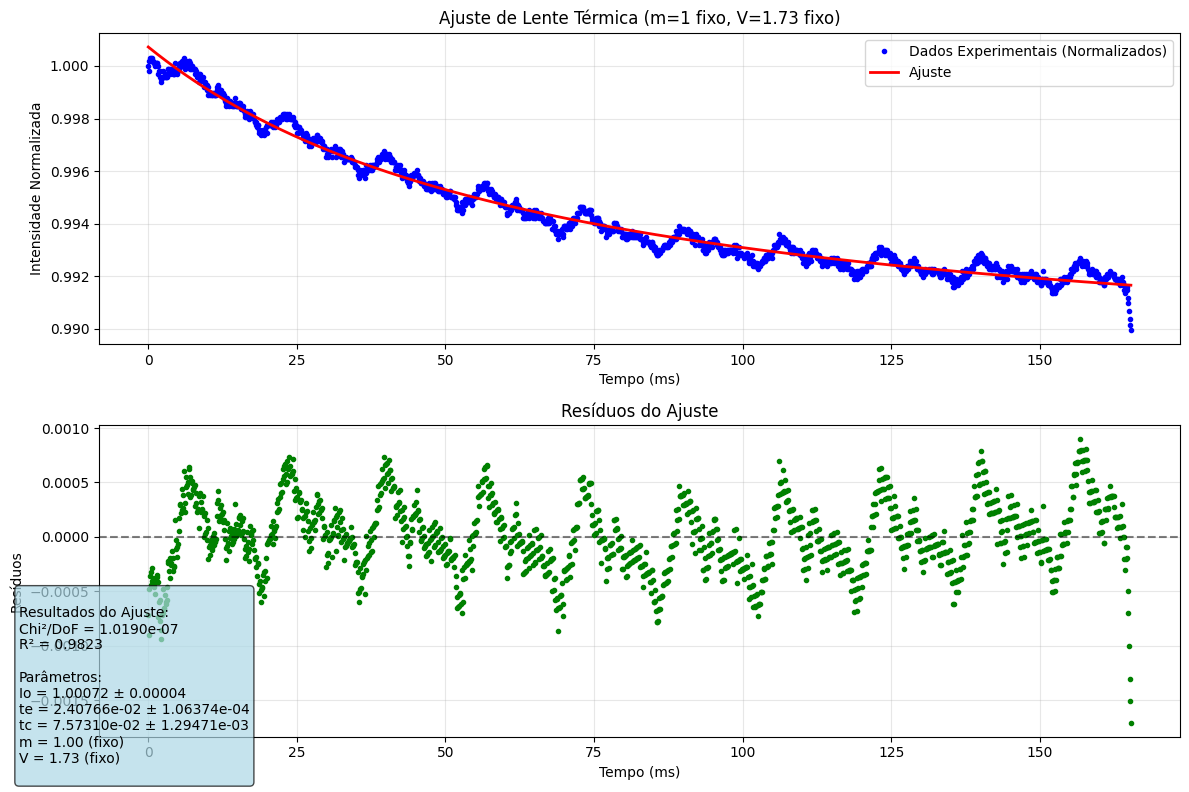


Resultados do Ajuste:
Chi²/DoF = 1.0190e-07
R² = 0.9823

Parâmetros:
Io = 1.00072 ± 0.00004
te = 2.40766e-02 ± 1.06374e-04
tc = 7.57310e-02 ± 1.29471e-03
m = 1.00 (fixo)
V = 1.73 (fixo)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

# ============================================================
# Função robusta de leitura
# ============================================================
def ler_dados_osciloscopio(filename):
    data = []
    try:
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()

        for line in lines:
            s = line.strip()
            if not s:
                continue
            if '\t' in s:
                parts = s.split('\t')
            else:
                parts = [p for p in s.split() if p]

            if len(parts) < 2:
                continue

            t_str = parts[0].replace(',', '.')
            y_str = parts[1].replace(',', '.')
            t_str = re.sub(r'[^\d\.\-\+eE]', '', t_str)
            y_str = re.sub(r'[^\d\.\-\+eE]', '', y_str)

            if not t_str or not y_str:
                continue

            try:
                t = float(t_str)
                y = float(y_str)
                if np.isfinite(t) and np.isfinite(y):
                    data.append([t, y])
            except Exception:
                continue

        if len(data) == 0:
            return None, None

        arr = np.array(data, dtype=float)
        return arr[:, 0], arr[:, 1]

    except Exception:
        return None, None

def separar_regiao_interesse(tempo, intensidade, threshold_factor=0.1):
    tempo = np.asarray(tempo, dtype=float)
    intensidade = np.asarray(intensidade, dtype=float)

    if len(tempo) == 0 or len(intensidade) == 0:
         return np.array([]), np.array([]), 0, 0

    max_idx = np.argmax(intensidade)
    max_intensity = intensidade[max_idx]
    min_intensity = np.min(intensidade)
    threshold = min_intensity + threshold_factor * (max_intensity - min_intensity)

    start_idx = 0
    for i in range(max_idx, -1, -1):
        if intensidade[i] < threshold:
            start_idx = i + 1
            break
    start_idx = min(start_idx + 5, max_idx)

    end_idx = len(intensidade) - 1
    for i in range(max_idx, len(intensidade)):
        if intensidade[i] < threshold:
            end_idx = i - 1
            break
    end_idx = max(end_idx - 5, max_idx)

    start_idx = max(0, start_idx)
    end_idx = min(len(intensidade) - 1, end_idx)

    if start_idx >= end_idx:
        return np.array([]), np.array([]), 0, 0

    return tempo[start_idx:end_idx], intensidade[start_idx:end_idx], start_idx, end_idx

def remover_pontos_extremidade(tempo, intensidade, pontos_remover=5):
    if len(tempo) <= 2 * pontos_remover:
        return tempo, intensidade
    return tempo[pontos_remover:-pontos_remover], intensidade[pontos_remover:-pontos_remover]

def normalizar_intensidade(intensidade):
    if len(intensidade) == 0:
        return np.array([])
    first_point = intensidade[0]
    if abs(first_point) < 1e-9:
        return intensidade / (first_point + 1e-9)
    else:
        return intensidade / first_point

# ============================================================
# Modelo com m fixo = 1
# ============================================================
def funcao_lente_termica(t, Io, te, tc, V=1.73, m=1.0):
    te = max(te, 1e-9)
    tc = max(tc, 1e-9)

    t = np.where(t == 0, 1e-9, t)

    termo1 = (1 + 2*m)**2 + V**2
    termo2 = tc / (2*t)

    denominador = termo1 * termo2 + 1 + 2*m + V**2
    denominador_safe = np.where(denominador == 0, 1e-9, denominador)

    argumento_atan = (2*m*V) / denominador_safe
    argumento_atan = np.clip(argumento_atan, -1e10, 1e10)

    termo_atan = np.arctan(argumento_atan)
    term_inside_square = 1 - (te/2.0) * termo_atan
    resultado = Io * (term_inside_square)**2
    return np.where(np.isfinite(resultado), resultado, np.nan)

def estimar_parametros_iniciais(tempo, intensity_norm):
    if len(tempo) == 0 or len(intensity_norm) == 0:
         return [1.0, 0.01, 0.1]

    Io_inicial = intensity_norm[0]
    te_inicial = (tempo[-1] - tempo[0]) * 0.05
    tc_inicial = (tempo[-1] - tempo[0]) * 0.5

    return [Io_inicial, te_inicial, tc_inicial]

def realizar_ajuste(tempo, intensity_norm, parametros_iniciais, max_iterations=200):
    if len(tempo) == 0 or len(intensity_norm) == 0:
         return None, None, None, None, None

    Io_init, te_init, tc_init = parametros_iniciais

    bounds_lower = [0.0, 1e-9, 1e-9]
    bounds_upper = [2.0, tempo[-1]-tempo[0], tempo[-1]-tempo[0]]

    try:
        popt, pcov = curve_fit(
            funcao_lente_termica,
            tempo,
            intensity_norm,
            p0=[Io_init, te_init, tc_init],
            bounds=(bounds_lower, bounds_upper),
            maxfev=max_iterations * 1000,
            method='trf'
        )

        erros = np.sqrt(np.diag(pcov))

        y_pred = funcao_lente_termica(tempo, *popt)
        ss_res = np.sum((intensity_norm - y_pred) ** 2)
        ss_tot = np.sum((intensity_norm - np.mean(intensity_norm)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

        n_params = len(popt)
        n_data = len(intensity_norm)
        dof = max(1, n_data - n_params)
        chi_squared = ss_res / dof

        return popt, erros, r_squared, chi_squared, y_pred

    except Exception as e:
        print(f"Erro no ajuste: {e}")
        return None, None, None, None, None

def plotar_resultados(tempo, intensidade_norm, tempo_ajuste, y_pred, parametros, erros, r_squared, chi_squared):
    if len(tempo) == 0 or len(intensidade_norm) == 0 or len(tempo_ajuste) == 0 or len(y_pred) == 0:
         return "Plotting failed due to empty data."

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(tempo * 1000, intensidade_norm, 'bo', markersize=3, label='Dados Experimentais (Normalizados)')
    plt.plot(tempo_ajuste * 1000, y_pred, 'r-', linewidth=2, label='Ajuste')
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Intensidade Normalizada')
    plt.title('Ajuste de Lente Térmica (m=1 fixo, V=1.73 fixo)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    residuos = intensidade_norm - y_pred
    plt.plot(tempo * 1000, residuos, 'go', markersize=3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Resíduos')
    plt.title('Resíduos do Ajuste')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if parametros is not None and len(parametros) >= 3:
        Io, te, tc = parametros
        if erros is not None and len(erros) >= 3:
            erro_Io, erro_te, erro_tc = erros
            texto_resultados = f"""
Resultados do Ajuste:
Chi²/DoF = {chi_squared:.4e}
R² = {r_squared:.4f}

Parâmetros:
Io = {Io:.5f} ± {erro_Io:.5f}
te = {te:.5e} ± {erro_te:.5e}
tc = {tc:.5e} ± {erro_tc:.5e}
m = 1.00 (fixo)
V = 1.73 (fixo)
"""
        else:
            texto_resultados = "Resultados do ajuste disponíveis, mas sem erros estimados."

    else:
        texto_resultados = "Resultados do ajuste não disponíveis."

    plt.figtext(0.02, 0.02, texto_resultados, fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

    plt.show()
    return texto_resultados

# ============================================================
# Função principal
# ============================================================
def analisar_lente_termica(filename="dados_osciloscopio66.txt"):
    print("=== ANÁLISE DE LENTE TÉRMICA (m=1 fixo, V=1.73 fixo) ===\n")

    tempo_full, intensidade_full = ler_dados_osciloscopio(filename)
    if tempo_full is None or intensidade_full is None or len(tempo_full) == 0:
        print("Erro ou dados vazios após leitura.")
        return

    tempo_roi, intensidade_roi, _, _ = separar_regiao_interesse(tempo_full, intensidade_full)
    tempo_clean, intensidade_clean = remover_pontos_extremidade(tempo_roi, intensidade_roi)
    intensidade_norm = normalizar_intensidade(intensidade_clean)

    if len(intensidade_norm) == 0:
        print("Dados insuficientes para análise.")
        return

    initial_params = estimar_parametros_iniciais(tempo_clean - tempo_clean[0], intensidade_norm)
    resultado = realizar_ajuste(tempo_clean - tempo_clean[0], intensidade_norm, initial_params)

    if resultado is None or resultado[0] is None:
        print("Falha no ajuste.")
        return

    parametros, erros, r_squared, chi_squared, y_pred = resultado
    texto_resultados = plotar_resultados(tempo_clean - tempo_clean[0], intensidade_norm,
                                         tempo_clean - tempo_clean[0], y_pred,
                                         parametros, erros, r_squared, chi_squared)
    print(texto_resultados)

# ============================================================
# Executa
# ============================================================
if __name__ == "__main__":
    analisar_lente_termica("1010novo.txt")



=== ANÁLISE DE LENTE TÉRMICA ===

Arquivo com 2483 pontos lidos.
Região selecionada automaticamente: idx 377 a 1420 (t=-0.0006 a 0.1036)
Região após limpeza: 1037 pontos.

Ajuste realizado!
I0 = 1.01684 ± 0.00010
te = 0.03610 ± 0.00297
tc = 0.18186 ± 0.02460
R² = 0.8364


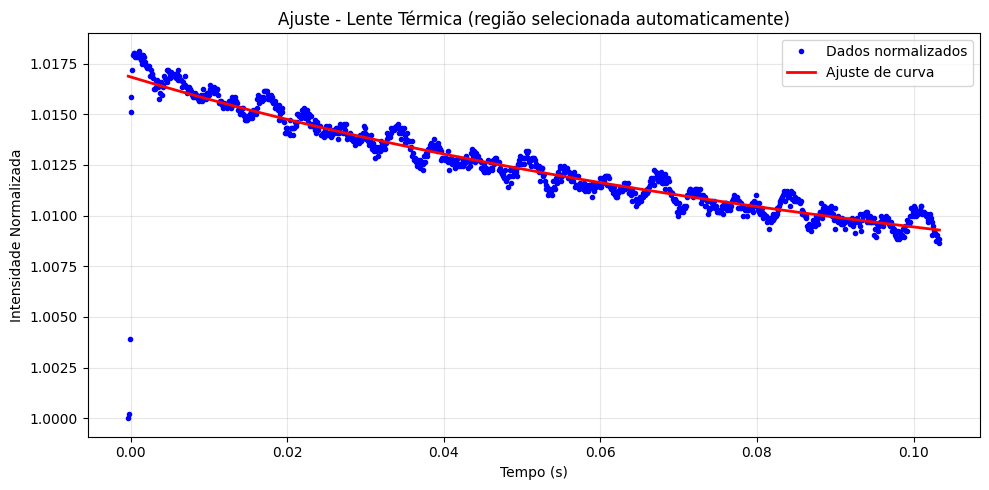

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def read_oscilloscope_data_br(filename):
    """Lê dados em formato brasileiro, vírgula decimal, TAB separador."""
    time_data = []
    intensity_data = []
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('\t')
                if len(parts) >= 2:
                    time_val = float(parts[0].replace(',', '.'))
                    intensity_val = float(parts[1].replace(',', '.'))
                    time_data.append(time_val)
                    intensity_data.append(intensity_val)
    return np.array(time_data), np.array(intensity_data)

def detect_thermal_lens_region(time, intensity):
    """
    Identifica automaticamente o pico de lente térmica e a região da curva de decaimento.
    Estratégia:
        - Detecta fundo (região de menor intensidade, média dos primeiros 10% dos dados)
        - Detecta pico (maior intensidade do sinal)
        - Seleciona intervalo indo do ponto que o sinal sobe >5% acima do fundo até ele retornar a menos de 50% do ganho total.
    """
    n = len(intensity)
    fundo = np.mean(intensity[:int(n*0.10)]) # fundo antes da curva
    pico_val = np.max(intensity)
    pico_idx = np.argmax(intensity)
    lim_sup = fundo + (pico_val - fundo) * 0.05
    lim_inf = pico_val - (pico_val - fundo) * 0.5

    # ponto inicial da curva (onde intensidade sobe mais de 5% do fundo)
    start_candidates = np.where(intensity[:pico_idx] < lim_sup)[0]
    start_idx = start_candidates[-1] if len(start_candidates) else 0

    # ponto final da curva (onde intensidade decai abaixo de lim_inf)
    end_candidates = np.where(intensity[pico_idx:] < lim_inf)[0]
    end_idx = pico_idx + end_candidates[0] if len(end_candidates) else n-1

    # Dá um pequeno afastamento na borda para remover ruído
    start_idx = max(0, start_idx - 2)
    end_idx = min(n-1, end_idx + 3)
    return start_idx, end_idx

def clean_data(time, intensity, remove_points=20):
    """Remove alguns pontos extremos para melhorar o ajuste"""
    if len(time) > 2 * remove_points:
        return time[remove_points:-remove_points], intensity[remove_points:-remove_points]
    else:
        return time, intensity

def normalize_intensity(intensity):
    """Normaliza pela intensidade inicial da curva (primeiro ponto da curva isolada)"""
    return intensity / intensity[0]

def estimate_initial_parameters(time, intensity):
    """
    Estima parâmetros iniciais a partir dos dados:
    - I0: primeiro valor (já robusto)
    - te: tempo para decair de 95% para 50% do máximo
    - tc: tempo para decair de 95% até próximo de fundo (1/e da amplitude), ou metade da extensão útil da curva
    """
    I0_guess = intensity[0]

    # Nivel máximo e mínimo (considerando algum ruído)
    y_max = np.max(intensity)
    y_min = np.min(intensity[-10:])  # considera média do fundo nos últimos pontos

    # 95% e 50% do máximo (em relação ao fundo)
    delta = y_max - y_min
    y_95 = y_min + 0.95 * delta
    y_50 = y_min + 0.50 * delta
    y_37 = y_min + 0.37 * delta  # 1/e para cauda
    t_95, t_50, t_37 = None, None, None

    for t, y in zip(time, intensity):
        if t_95 is None and y < y_95:
            t_95 = t
        if t_50 is None and y < y_50:
            t_50 = t
        if t_37 is None and y < y_37:
            t_37 = t
        if t_95 and t_50 and t_37:
            break

    # Estimativas baseadas no tempo real
    te_guess = abs(t_50 - t_95) if t_95 and t_50 else 0.025
    tc_guess = abs(t_37 - t_95) if t_95 and t_37 else (time[-1] - time[0]) / 2.

    # Evite valores inválidos
    if te_guess < 1e-4: te_guess = 0.02
    if tc_guess < 1e-4: tc_guess = 0.04

    return I0_guess, te_guess, tc_guess


def thermal_lens_function(t, I0, te, tc, m=1, V=1.73):
    """Função modelo da lente térmica"""
    numerator = 2 * m * V
    denominator = ((1 + 2*m)**2 + V**2)*(tc/(2*t)) + 1 + 2*m + V**2
    atan_term = np.arctan(numerator / denominator)
    return I0 * (1 - (te/2)*atan_term)**2

def analyze_thermal_lens_data_br(filename, plot_results=True):
    print("\n=== ANÁLISE DE LENTE TÉRMICA ===\n")
    time, intensity = read_oscilloscope_data_br(filename)
    print(f"Arquivo com {len(time)} pontos lidos.")

    # Seleção automática da região útil!
    start_idx, end_idx = detect_thermal_lens_region(time, intensity)
    region_time = time[start_idx:end_idx]
    region_intensity = intensity[start_idx:end_idx]
    print(f"Região selecionada automaticamente: idx {start_idx} a {end_idx} (t={region_time[0]:.4f} a {region_time[-1]:.4f})")

    # Limpa extremos e normaliza
    region_time, region_intensity = clean_data(region_time, region_intensity, remove_points=3)
    region_intensity_norm = normalize_intensity(region_intensity)
    print(f"Região após limpeza: {len(region_time)} pontos.")

    # Parâmetros iniciais e ajuste
    I0_guess, te_guess, tc_guess = estimate_initial_parameters(region_time, region_intensity_norm)

    try:
        popt, pcov = curve_fit(
            lambda t, I0, te, tc: thermal_lens_function(t, I0, te, tc, m=1, V=1.73),
            region_time, region_intensity_norm,
            p0=[I0_guess, te_guess, tc_guess],
            bounds=([0.95, 0.001, 0.001], [1.05, 0.1, 0.2]),
            maxfev=1000,
            method='trf'
        )
        I0_fit, te_fit, tc_fit = popt
        errors = np.sqrt(np.diag(pcov))
        I0_err, te_err, tc_err = errors
        y_pred = thermal_lens_function(region_time, *popt, m=1, V=1.73)
        ss_res = np.sum((region_intensity_norm - y_pred) ** 2)
        ss_tot = np.sum((region_intensity_norm - np.mean(region_intensity_norm)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        chi_squared = ss_res / (len(region_time) - len(popt))
        print(f"\nAjuste realizado!")
        print(f"I0 = {I0_fit:.5f} ± {I0_err:.5f}")
        print(f"te = {te_fit:.5f} ± {te_err:.5f}")
        print(f"tc = {tc_fit:.5f} ± {tc_err:.5f}")
        print(f"R² = {r_squared:.4f}")

        if plot_results:
            plt.figure(figsize=(10,5))
            plt.plot(region_time, region_intensity_norm, 'bo', ms=3, label='Dados normalizados')
            plt.plot(region_time, y_pred, 'r-', lw=2, label='Ajuste de curva')
            plt.xlabel('Tempo (s)')
            plt.ylabel('Intensidade Normalizada')
            plt.title('Ajuste - Lente Térmica (região selecionada automaticamente)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        return {
            'I0': I0_fit, 'te': te_fit, 'tc': tc_fit,
            'I0_err': I0_err, 'te_err': te_err, 'tc_err': tc_err,
            'R2': r_squared, 'chi2': chi_squared
        }
    except Exception as e:
        print(f"Erro no ajuste: {e}")
        return None

# --- EXECUÇÃO DIRETA ---
if __name__ == "__main__":
    analyze_thermal_lens_data_br("1111 novo.txt", plot_results=True)


=== ANÁLISE DE LENTE TÉRMICA (m=1 fixo, V=1.73 fixo) ===



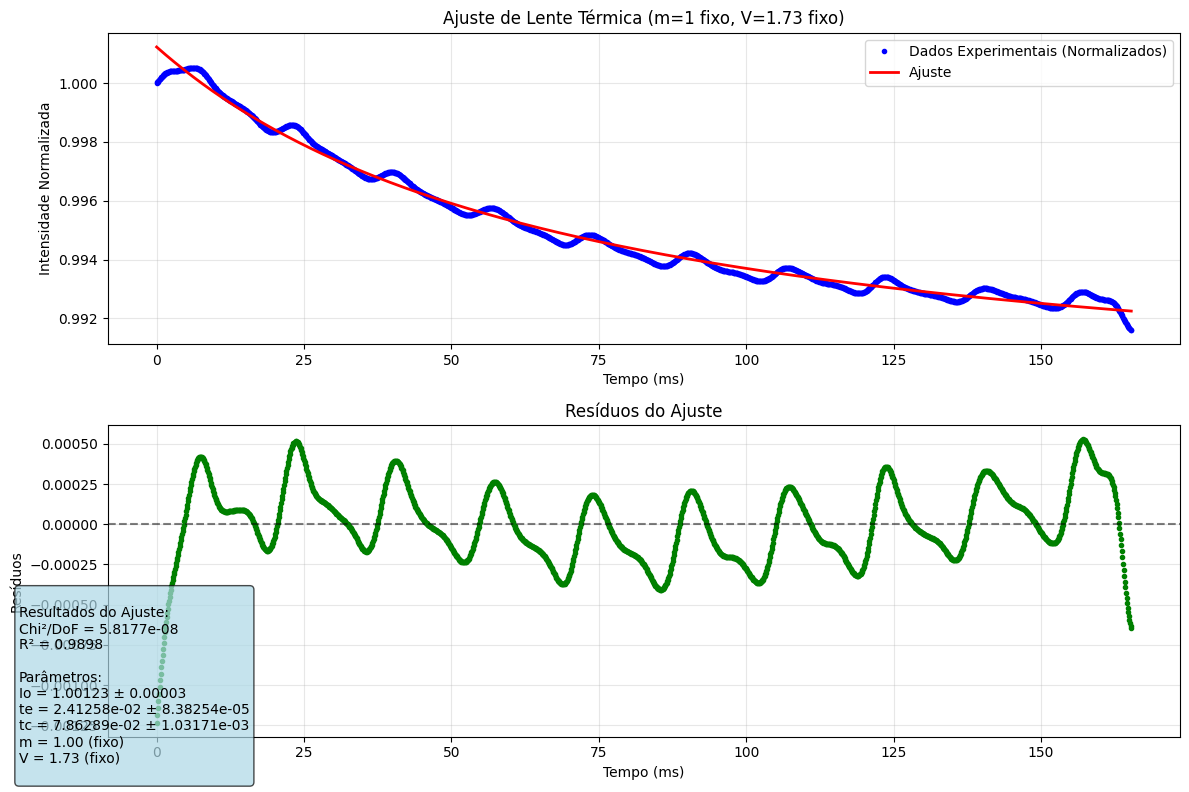


Resultados do Ajuste:
Chi²/DoF = 5.8177e-08
R² = 0.9898

Parâmetros:
Io = 1.00123 ± 0.00003
te = 2.41258e-02 ± 8.38254e-05
tc = 7.86289e-02 ± 1.03171e-03
m = 1.00 (fixo)
V = 1.73 (fixo)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
from scipy.signal import butter, filtfilt, medfilt, savgol_filter

# ----------------------- CONFIGURAÇÃO DE FILTRO -----------------------
# Ative/desative filtro e escolha parâmetros aqui
APPLY_FILTER = True             # True para aplicar filtragem antes da normalização
FILTER_PIPELINE = ['median', 'butter']  # ordem de etapas possíveis: 'median','butter','savgol','moving'
# Butterworth params
BUTTER_FC = 200.0   # frequência de corte (Hz) — ajuste conforme seu sinal
BUTTER_ORDER = 4    # ordem do Butterworth
# Mediana params
MEDIAN_KERNEL_MS = 5.0   # tamanho do kernel em ms (ajuste)
# Savitzky-Golay params (se usar)
SG_WINDOW_MS = 20.0
SG_POLYORDER = 2
# Média móvel params (se usar)
MOVING_WINDOW_MS = 10.0
# ---------------------------------------------------------------------

# ============================================================
# Função robusta de leitura
# ============================================================
def ler_dados_osciloscopio(filename):
    data = []
    try:
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()

        for line in lines:
            s = line.strip()
            if not s:
                continue
            if '\t' in s:
                parts = s.split('\t')
            else:
                parts = [p for p in s.split() if p]

            if len(parts) < 2:
                continue

            t_str = parts[0].replace(',', '.')
            y_str = parts[1].replace(',', '.')
            t_str = re.sub(r'[^\d\.\-\+eE]', '', t_str)
            y_str = re.sub(r'[^\d\.\-\+eE]', '', y_str)

            if not t_str or not y_str:
                continue

            try:
                t = float(t_str)
                y = float(y_str)
                if np.isfinite(t) and np.isfinite(y):
                    data.append([t, y])
            except Exception:
                continue

        if len(data) == 0:
            return None, None

        arr = np.array(data, dtype=float)
        # garante ordenação por tempo
        idx_sort = np.argsort(arr[:,0])
        arr = arr[idx_sort]
        return arr[:, 0], arr[:, 1]

    except Exception:
        return None, None

def separar_regiao_interesse(tempo, intensidade, threshold_factor=0.1):
    tempo = np.asarray(tempo, dtype=float)
    intensidade = np.asarray(intensidade, dtype=float)

    if len(tempo) == 0 or len(intensidade) == 0:
         return np.array([]), np.array([]), 0, 0

    max_idx = np.argmax(intensidade)
    max_intensity = intensidade[max_idx]
    min_intensity = np.min(intensidade)
    threshold = min_intensity + threshold_factor * (max_intensity - min_intensity)

    start_idx = 0
    for i in range(max_idx, -1, -1):
        if intensidade[i] < threshold:
            start_idx = i + 1
            break
    start_idx = min(start_idx + 5, max_idx)

    end_idx = len(intensidade) - 1
    for i in range(max_idx, len(intensidade)):
        if intensidade[i] < threshold:
            end_idx = i - 1
            break
    end_idx = max(end_idx - 5, max_idx)

    start_idx = max(0, start_idx)
    end_idx = min(len(intensidade) - 1, end_idx)

    if start_idx >= end_idx:
        return np.array([]), np.array([]), 0, 0

    return tempo[start_idx:end_idx], intensidade[start_idx:end_idx], start_idx, end_idx

def remover_pontos_extremidade(tempo, intensidade, pontos_remover=5):
    if len(tempo) <= 2 * pontos_remover:
        return tempo, intensidade
    return tempo[pontos_remover:-pontos_remover], intensidade[pontos_remover:-pontos_remover]

def normalizar_intensidade(intensidade):
    if len(intensidade) == 0:
        return np.array([])
    first_point = intensidade[0]
    if abs(first_point) < 1e-9:
        return intensidade / (first_point + 1e-9)
    else:
        return intensidade / first_point

# ---------------------- Funções de filtragem -------------------------
def estimate_fs_from_time(t):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        return None
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return None
    dt_mean = np.mean(dt)
    if dt_mean <= 0:
        return None
    return 1.0 / dt_mean

def butter_lowpass_filter(data, fc, fs, order=4):
    if fs is None or fs <= 0:
        return data
    nyq = 0.5 * fs
    Wn = float(fc) / nyq
    if Wn >= 1.0:
        # corte acima Nyquist -> não filtrar
        return data
    if Wn <= 0:
        return data
    try:
        b, a = butter(order, Wn, btype='low', analog=False)
        # filtfilt garante resposta sem deslocamento de fase
        y = filtfilt(b, a, data, method="pad")
        return y
    except Exception:
        # em caso de erro (dados curtos, etc) retorna dados originais
        return data

def apply_median(data, kernel_samples):
    if kernel_samples <= 1 or len(data) < 3:
        return data
    k = int(kernel_samples)
    if k % 2 == 0:
        k += 1
    # medfilt precisa de kernel impar >=3
    if k < 3:
        k = 3
    # se houver menos pontos que kernel, apenas retorna original
    if len(data) < k:
        return data
    try:
        return medfilt(data, kernel_size=k)
    except Exception:
        return data

def apply_savgol(data, window_samples, polyorder):
    if window_samples <= 1 or len(data) < 3:
        return data
    w = int(window_samples)
    if w % 2 == 0:
        w += 1
    if w <= polyorder:
        w = polyorder + 2
        if w % 2 == 0:
            w += 1
    if len(data) < w:
        return data
    try:
        return savgol_filter(data, window_length=w, polyorder=polyorder)
    except Exception:
        return data

def apply_moving_average(data, window_samples):
    w = int(window_samples)
    if w <= 1:
        return data
    if len(data) < w:
        return data
    return np.convolve(data, np.ones(w)/w, mode='same')

def aplicar_pipeline_filtro(tempo, intensidade):
    if not APPLY_FILTER:
        return intensidade  # sem alteração

    fs = estimate_fs_from_time(tempo)
    # converter janelas ms -> amostras (cuidando se fs não estimado)
    if fs is None:
        # se não é possível estimar fs, aplica apenas mediana com kernel pequeno
        kernel_samples = 3
        return apply_median(intensidade, kernel_samples)

    # calcular amostras para kernels
    median_kernel_samples = max(1, int(round((MEDIAN_KERNEL_MS / 1000.0) * fs)))
    sg_window_samples = max(1, int(round((SG_WINDOW_MS / 1000.0) * fs)))
    moving_window_samples = max(1, int(round((MOVING_WINDOW_MS / 1000.0) * fs)))

    y = intensidade.copy()

    for step in FILTER_PIPELINE:
        if step == 'median':
            y = apply_median(y, median_kernel_samples)
        elif step == 'butter':
            # usa BUTTER_FC e BUTTER_ORDER definidos globalmente
            y = butter_lowpass_filter(y, BUTTER_FC, fs, order=BUTTER_ORDER)
        elif step == 'savgol':
            y = apply_savgol(y, sg_window_samples, SG_POLYORDER)
        elif step == 'moving':
            y = apply_moving_average(y, moving_window_samples)
        else:
            # desconhecido -> pular
            pass

    return y

# ============================================================
# Modelo com m fixo = 1
# ============================================================
def funcao_lente_termica(t, Io, te, tc, V=1.73, m=1.0):
    te = max(te, 1e-9)
    tc = max(tc, 1e-9)

    t = np.where(t == 0, 1e-9, t)

    termo1 = (1 + 2*m)**2 + V**2
    termo2 = tc / (2*t)

    denominador = termo1 * termo2 + 1 + 2*m + V**2
    denominador_safe = np.where(denominador == 0, 1e-9, denominador)

    argumento_atan = (2*m*V) / denominador_safe
    argumento_atan = np.clip(argumento_atan, -1e10, 1e10)

    termo_atan = np.arctan(argumento_atan)
    term_inside_square = 1 - (te/2.0) * termo_atan
    resultado = Io * (term_inside_square)**2
    return np.where(np.isfinite(resultado), resultado, np.nan)

def estimar_parametros_iniciais(tempo, intensity_norm):
    if len(tempo) == 0 or len(intensity_norm) == 0:
         return [1.0, 0.01, 0.1]

    Io_inicial = intensity_norm[0]
    te_inicial = (tempo[-1] - tempo[0]) * 0.05
    tc_inicial = (tempo[-1] - tempo[0]) * 0.5

    return [Io_inicial, te_inicial, tc_inicial]

def realizar_ajuste(tempo, intensity_norm, parametros_iniciais, max_iterations=200):
    if len(tempo) == 0 or len(intensity_norm) == 0:
         return None, None, None, None, None

    Io_init, te_init, tc_init = parametros_iniciais

    bounds_lower = [0.0, 1e-9, 1e-9]
    bounds_upper = [2.0, tempo[-1]-tempo[0], tempo[-1]-tempo[0]]

    try:
        popt, pcov = curve_fit(
            funcao_lente_termica,
            tempo,
            intensity_norm,
            p0=[Io_init, te_init, tc_init],
            bounds=(bounds_lower, bounds_upper),
            maxfev=max_iterations * 1000,
            method='trf'
        )

        erros = np.sqrt(np.diag(pcov))

        y_pred = funcao_lente_termica(tempo, *popt)
        ss_res = np.sum((intensity_norm - y_pred) ** 2)
        ss_tot = np.sum((intensity_norm - np.mean(intensity_norm)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

        n_params = len(popt)
        n_data = len(intensity_norm)
        dof = max(1, n_data - n_params)
        chi_squared = ss_res / dof

        return popt, erros, r_squared, chi_squared, y_pred

    except Exception as e:
        print(f"Erro no ajuste: {e}")
        return None, None, None, None, None

def plotar_resultados(tempo, intensidade_norm, tempo_ajuste, y_pred, parametros, erros, r_squared, chi_squared):
    if len(tempo) == 0 or len(intensidade_norm) == 0 or len(tempo_ajuste) == 0 or len(y_pred) == 0:
         return "Plotting failed due to empty data."

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(tempo * 1000, intensidade_norm, 'bo', markersize=3, label='Dados Experimentais (Normalizados)')
    plt.plot(tempo_ajuste * 1000, y_pred, 'r-', linewidth=2, label='Ajuste')
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Intensidade Normalizada')
    plt.title('Ajuste de Lente Térmica (m=1 fixo, V=1.73 fixo)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    residuos = intensidade_norm - y_pred
    plt.plot(tempo * 1000, residuos, 'go', markersize=3)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.xlabel('Tempo (ms)')
    plt.ylabel('Resíduos')
    plt.title('Resíduos do Ajuste')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if parametros is not None and len(parametros) >= 3:
        Io, te, tc = parametros
        if erros is not None and len(erros) >= 3:
            erro_Io, erro_te, erro_tc = erros
            texto_resultados = f"""
Resultados do Ajuste:
Chi²/DoF = {chi_squared:.4e}
R² = {r_squared:.4f}

Parâmetros:
Io = {Io:.5f} ± {erro_Io:.5f}
te = {te:.5e} ± {erro_te:.5e}
tc = {tc:.5e} ± {erro_tc:.5e}
m = 1.00 (fixo)
V = 1.73 (fixo)
"""
        else:
            texto_resultados = "Resultados do ajuste disponíveis, mas sem erros estimados."

    else:
        texto_resultados = "Resultados do ajuste não disponíveis."

    plt.figtext(0.02, 0.02, texto_resultados, fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

    plt.show()
    return texto_resultados

# ============================================================
# Função principal
# ============================================================
def analisar_lente_termica(filename="dados_osciloscopio66.txt"):
    print("=== ANÁLISE DE LENTE TÉRMICA (m=1 fixo, V=1.73 fixo) ===\n")

    tempo_full, intensidade_full = ler_dados_osciloscopio(filename)
    if tempo_full is None or intensidade_full is None or len(tempo_full) == 0:
        print("Erro ou dados vazios após leitura.")
        return

    tempo_roi, intensidade_roi, _, _ = separar_regiao_interesse(tempo_full, intensidade_full)
    tempo_clean, intensidade_clean = remover_pontos_extremidade(tempo_roi, intensidade_roi)

    if len(intensidade_clean) == 0:
        print("Dados insuficientes para análise.")
        return

    # -------------------- APLICA FILTRAGEM AQUI (antes da normalização) --------------------
    intensidade_filtrada = intensidade_clean.copy()
    if APPLY_FILTER:
        intensidade_filtrada = aplicar_pipeline_filtro(tempo_clean, intensidade_clean)
    # --------------------------------------------------------------------------------------

    intensidade_norm = normalizar_intensidade(intensidade_filtrada)

    if len(intensidade_norm) == 0:
        print("Dados insuficientes para análise.")
        return

    # nota: tempo passado para estimativa/ajuste é deslocado para começar em zero
    tempo_rel = tempo_clean - tempo_clean[0]

    initial_params = estimar_parametros_iniciais(tempo_rel, intensidade_norm)
    resultado = realizar_ajuste(tempo_rel, intensidade_norm, initial_params)

    if resultado is None or resultado[0] is None:
        print("Falha no ajuste.")
        return

    parametros, erros, r_squared, chi_squared, y_pred = resultado
    texto_resultados = plotar_resultados(tempo_rel, intensidade_norm,
                                         tempo_rel, y_pred,
                                         parametros, erros, r_squared, chi_squared)
    print(texto_resultados)

# ============================================================
# Executa
# ============================================================
if __name__ == "__main__":
    analisar_lente_termica("1010novo.txt")


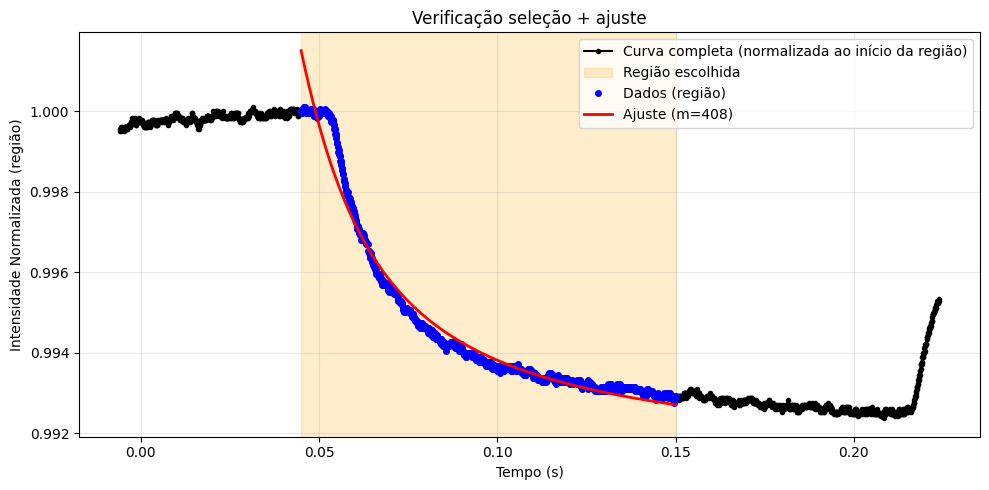

Ajuste realizado com sucesso!
I0 = 1.001501 ± 0.000078
te = 0.009855 ± 0.001182
tc = 0.000100 ± 0.005269
m  = 407.889404 ± 21516.300115
R² = 0.97588
χ² reduzido = 1.122e-07
Região usada: t = 0.045000 → 0.150000 (idx 508–1558)


=== ANÁLISE DE LENTE TÉRMICA (MODELO DIFUSIVO) ===
Ajuste final:
I0 = 1.000164 ± 0.000024
A  = 0.006144 ± 0.000030
tc = 18.844043 ± 0.107740 ms
m  = 0.778490 ± 0.005958
R² = 0.99731


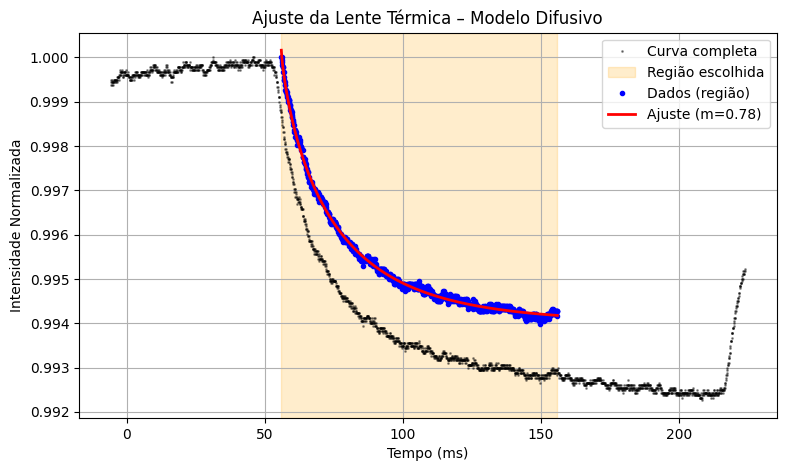

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

# ============================================================
# Leitura
# ============================================================
def read_oscilloscope_data_br(filename):
    t, I = [], []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().replace(',', '.').split('\t')
            if len(parts) >= 2:
                try:
                    t.append(float(parts[0]))
                    I.append(float(parts[1]))
                except ValueError:
                    continue
    return np.array(t), np.array(I)

# ============================================================
# Modelo empírico mais estável
# ============================================================
def model_diffusive(t, I0, A, tc, m):
    t = np.maximum(t - t[0], 0)
    return I0 * (1 - A * (1 - np.exp(-(t / tc) ** m)))

# ============================================================
# Análise principal
# ============================================================
def analyze_thermal_lens(filename, m_init=15, V=1.73, plot_results=True):
    print("=== ANÁLISE DE LENTE TÉRMICA (MODELO DIFUSIVO) ===")
    t, I = read_oscilloscope_data_br(filename)

    # --- Pré-processamento ---
    I = I / np.max(I)
    t = t * 1000  # converte para milissegundos

    I_smooth = savgol_filter(I, 51, 3)
    dI_dt = np.gradient(I_smooth, t)

    # Início do decaimento
    idx_start = np.argmin(dI_dt)
    t_start = t[idx_start]
    window = 100  # ms
    t_end = t_start + window

    mask = (t >= t_start) & (t <= t_end)
    t_reg = t[mask]
    I_reg = I[mask]

    # Normalização local
    I_reg = I_reg / np.max(I_reg)

    # --- Ajuste ---
    try:
        popt, pcov = curve_fit(
            model_diffusive,
            t_reg,
            I_reg,
            p0=[1.0, 0.01, 20, m_init],
            bounds=([0.9, 0.0001, 0.1, 0.5], [1.1, 0.1, 1000, 50]),
            maxfev=20000
        )
        perr = np.sqrt(np.diag(pcov))
        I0, A, tc, m = popt
        I_fit = model_diffusive(t_reg, *popt)
        R2 = 1 - np.sum((I_reg - I_fit)**2) / np.sum((I_reg - np.mean(I_reg))**2)

        print(f"Ajuste final:")
        print(f"I0 = {I0:.6f} ± {perr[0]:.6f}")
        print(f"A  = {A:.6f} ± {perr[1]:.6f}")
        print(f"tc = {tc:.6f} ± {perr[2]:.6f} ms")
        print(f"m  = {m:.6f} ± {perr[3]:.6f}")
        print(f"R² = {R2:.5f}")

    except Exception as e:
        print("❌ Falha no ajuste:", e)
        return

    # --- Gráfico ---
    if plot_results:
        plt.figure(figsize=(9, 5))
        plt.plot(t, I, 'k.', ms=2, alpha=0.4, label='Curva completa')
        plt.axvspan(t_start, t_end, color='orange', alpha=0.2, label='Região escolhida')
        plt.plot(t_reg, I_reg, 'b.', label='Dados (região)')
        plt.plot(t_reg, I_fit, 'r-', lw=2, label=f"Ajuste (m={m:.2f})")
        plt.xlabel("Tempo (ms)")
        plt.ylabel("Intensidade Normalizada")
        plt.legend()
        plt.title("Ajuste da Lente Térmica – Modelo Difusivo")
        plt.grid(True)
        plt.show()


# ============================================================
# Execução
# ============================================================
if __name__ == "__main__":
    analyze_thermal_lens("77.txt", m_init=15, V=1.73)


=== AJUSTE DE LENTE TÉRMICA (m VARIÁVEL) ===
Arquivo: 77.txt
Parâmetros ajustados:
I0 = 1.428214
te = 0.013568
tc = 0.002370
m  = 99.999997

Incertezas:
dI0 = 0.000128
dte = 0.004794
dtc = 0.084093
dm  = 3555.844299


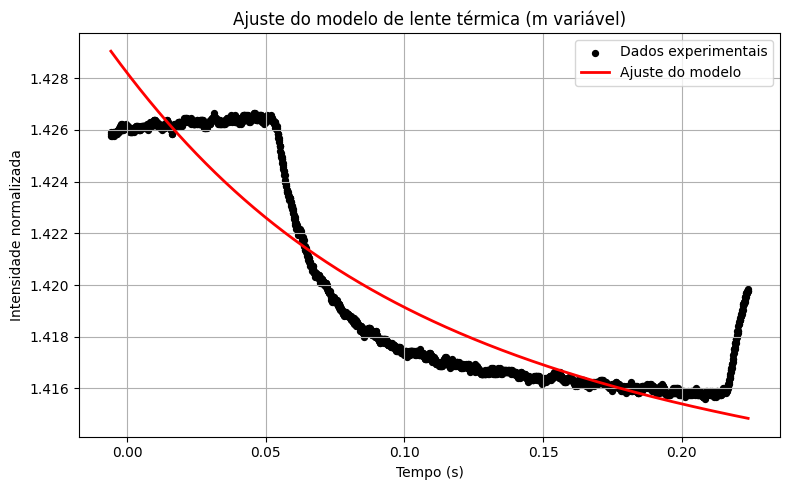

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Função modelo da lente térmica
# ============================================================
def modelo_lente_termica(t, I0, te, tc, m):
    V = 1.73  # valor fixo
    # Evita divisão por zero
    t = np.where(t == 0, 1e-9, t)
    numerator = 2 * m * V
    denominator = ((1 + 2*m)**2 + V**2) * (tc / (2*t)) + 1 + 2*m + V**2
    atan_term = np.arctan(numerator / denominator)
    return I0 * (1 - (te / 2) * atan_term)**2

# ============================================================
# Leitura dos dados experimentais (com vírgula decimal)
# ============================================================
arquivo = "77.txt"  # nome do arquivo

# Converte vírgulas em pontos antes de carregar
with open(arquivo, 'r', encoding='utf-8') as f:
    linhas = f.readlines()

linhas_convertidas = [linha.replace(',', '.') for linha in linhas]
dados = np.loadtxt(linhas_convertidas)

t = dados[:, 0]
I = dados[:, 1]

# ============================================================
# Parâmetros iniciais
# ============================================================
I0_inicial = max(I)
te_inicial = 0.002
tc_inicial = 0.03
m_inicial = 14.9484

p0 = [I0_inicial, te_inicial, tc_inicial, m_inicial]
limites = ([0, 0, 0, 0], [np.inf, 1, 10, 100])

# ============================================================
# Ajuste de curva
# ============================================================
try:
    popt, pcov = curve_fit(modelo_lente_termica, t, I, p0=p0, bounds=limites, maxfev=20000)
    I0_fit, te_fit, tc_fit, m_fit = popt

    print("=== AJUSTE DE LENTE TÉRMICA (m VARIÁVEL) ===")
    print(f"Arquivo: {arquivo}")
    print(f"Parâmetros ajustados:")
    print(f"I0 = {I0_fit:.6f}")
    print(f"te = {te_fit:.6f}")
    print(f"tc = {tc_fit:.6f}")
    print(f"m  = {m_fit:.6f}")

    perr = np.sqrt(np.diag(pcov))
    print("\nIncertezas:")
    print(f"dI0 = {perr[0]:.6f}")
    print(f"dte = {perr[1]:.6f}")
    print(f"dtc = {perr[2]:.6f}")
    print(f"dm  = {perr[3]:.6f}")

    I_fit = modelo_lente_termica(t, *popt)

    # ============================================================
    # Plotagem
    # ============================================================
    plt.figure(figsize=(8,5))
    plt.scatter(t, I, s=18, label='Dados experimentais', color='black')
    plt.plot(t, I_fit, 'r-', linewidth=2, label='Ajuste do modelo')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Intensidade normalizada')
    plt.title('Ajuste do modelo de lente térmica (m variável)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except RuntimeError as e:
    print("Falha no ajuste:", e)
except Exception as e:
    print("Erro inesperado:", e)


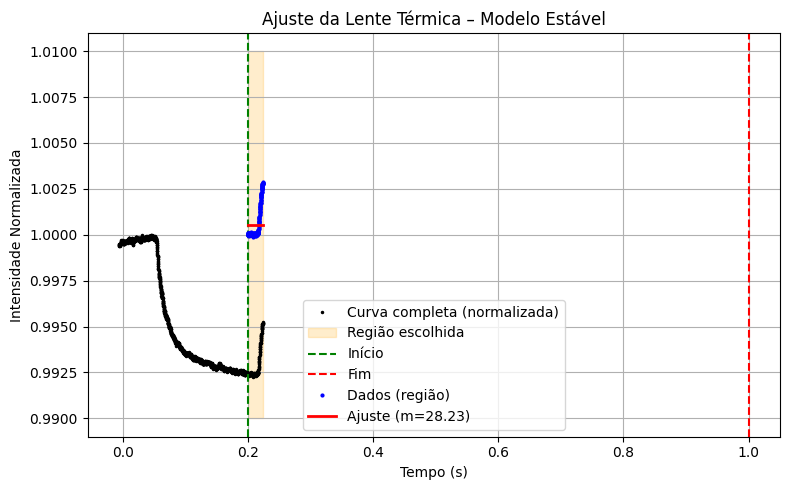

=== ANÁLISE DE LENTE TÉRMICA (MÉTODO ESTÁVEL) ===
Ajuste final realizado na região [0.200 s, 1.000 s]
I0 = 1.000553 ± 0.001764
te = 0.000000 ± 0.684092
tc = 4.857136 ± 0.000000
m  = 28.229382 ± 0.000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Função modelo da lente térmica
# ============================================================
def modelo_lente_termica(t, I0, te, tc, m):
    V = 1.73  # fixo
    t = np.where(t == 0, 1e-9, t)
    numerator = 2 * m * V
    denominator = ((1 + 2*m)**2 + V**2) * (tc / (2*t)) + 1 + 2*m + V**2
    atan_term = np.arctan(numerator / denominator)
    return I0 * (1 - (te / 2) * atan_term)**2


# ============================================================
# Leitura dos dados (vírgula decimal)
# ============================================================
arquivo = "77.txt"

with open(arquivo, 'r', encoding='utf-8') as f:
    linhas = [linha.replace(',', '.') for linha in f.readlines() if linha.strip()]

dados = np.loadtxt(linhas)
t = dados[:, 0]
I = dados[:, 1]

# ============================================================
# Normalização (para comparação visual)
# ============================================================
I = I / np.max(I)

# ============================================================
# Seleção da região de ajuste
# ============================================================
# Você pode alterar manualmente estes limites:
inicio = 0.2      # tempo inicial da região (em segundos, por exemplo)
fim = 1.0         # tempo final da região

# Identifica os índices correspondentes
mask = (t >= inicio) & (t <= fim)
t_regiao = t[mask]
I_regiao = I[mask]

# Normaliza à intensidade no início da região
I_regiao = I_regiao / I_regiao[0]
I_total_norm = I / I_regiao[0]

# ============================================================
# Parâmetros iniciais e limites
# ============================================================
p0 = [1.0, 0.002, 0.03, 15]
limites = ([0, 0, 0, 0], [2, 1, 10, 200])

# ============================================================
# Ajuste apenas na região escolhida
# ============================================================
popt, pcov = curve_fit(modelo_lente_termica, t_regiao, I_regiao,
                       p0=p0, bounds=limites, maxfev=20000)

I0_fit, te_fit, tc_fit, m_fit = popt
I_fit_regiao = modelo_lente_termica(t_regiao, *popt)

# ============================================================
# Plotagem completa com destaque da região
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(t, I_total_norm, 'k.', markersize=3, label='Curva completa (normalizada)')
plt.fill_between(t, 0.99, 1.01, where=mask, color='orange', alpha=0.2, label='Região escolhida')
plt.axvline(inicio, color='green', linestyle='--', label='Início')
plt.axvline(fim, color='red', linestyle='--', label='Fim')
plt.plot(t_regiao, I_regiao, 'b.', markersize=4, label='Dados (região)')
plt.plot(t_regiao, I_fit_regiao, 'r-', linewidth=2, label=f'Ajuste (m={m_fit:.2f})')
plt.xlabel('Tempo (s)')
plt.ylabel('Intensidade Normalizada')
plt.title('Ajuste da Lente Térmica – Modelo Estável')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Resultados numéricos
# ============================================================
perr = np.sqrt(np.diag(pcov))
print("=== ANÁLISE DE LENTE TÉRMICA (MÉTODO ESTÁVEL) ===")
print(f"Ajuste final realizado na região [{inicio:.3f} s, {fim:.3f} s]")
print(f"I0 = {I0_fit:.6f} ± {perr[0]:.6f}")
print(f"te = {te_fit:.6f} ± {perr[1]:.6f}")
print(f"tc = {tc_fit:.6f} ± {perr[2]:.6f}")
print(f"m  = {m_fit:.6f} ± {perr[3]:.6f}")


/tmp/ipython-input-3206518333.py:72: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(modelo_lente_termica, t_regiao, I_regiao,


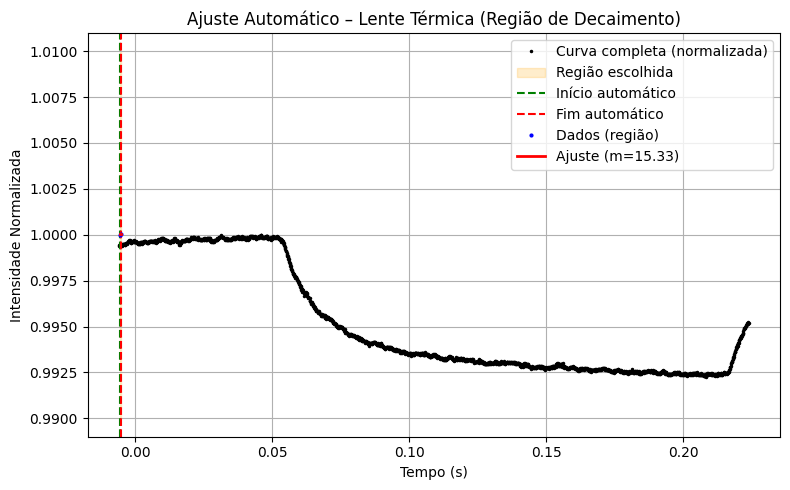

=== ANÁLISE DE LENTE TÉRMICA (MÉTODO ESTÁVEL) ===
Ajuste final realizado automaticamente entre -0.00530s e -0.00520s
I0 = 1.000028 ± inf
te = 0.000012 ± inf
tc = 0.647070 ± inf
m  = 15.326503 ± inf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Função modelo da lente térmica
# ============================================================
def modelo_lente_termica(t, I0, te, tc, m):
    V = 1.73  # fixo
    t = np.where(t == 0, 1e-9, t)
    numerator = 2 * m * V
    denominator = ((1 + 2*m)**2 + V**2) * (tc / (2*t)) + 1 + 2*m + V**2
    atan_term = np.arctan(numerator / denominator)
    return I0 * (1 - (te / 2) * atan_term)**2


# ============================================================
# Leitura dos dados (com vírgulas)
# ============================================================
arquivo = "77.txt"

with open(arquivo, 'r', encoding='utf-8') as f:
    linhas = [linha.replace(',', '.') for linha in f.readlines() if linha.strip()]

dados = np.loadtxt(linhas)
t = dados[:, 0]
I = dados[:, 1]

# ============================================================
# Normalização e suavização leve
# ============================================================
I = I / np.max(I)
I_smooth = np.convolve(I, np.ones(5)/5, mode='same')

# ============================================================
# Detecção automática da região de decaimento
# ============================================================
dI = np.gradient(I_smooth, t)
negativos = np.where(dI < -1e-5)[0]  # início do decaimento
positivos = np.where(dI > 0)[0]      # onde volta a subir

if len(negativos) > 0:
    i_inicio = negativos[0]
else:
    i_inicio = 0

# fim é o primeiro ponto positivo depois do início
if len(positivos) > 0:
    i_fim_candidates = positivos[positivos > i_inicio]
    i_fim = i_fim_candidates[0] if len(i_fim_candidates) > 0 else len(t)-1
else:
    i_fim = len(t) - 1

inicio = t[i_inicio]
fim = t[i_fim]

# ============================================================
# Seleção e normalização da região
# ============================================================
mask = (t >= inicio) & (t <= fim)
t_regiao = t[mask]
I_regiao = I[mask]
I_regiao = I_regiao / I_regiao[0]
I_total_norm = I / I_regiao[0]

# ============================================================
# Ajuste do modelo
# ============================================================
p0 = [1.0, 0.002, 0.03, 15]
limites = ([0, 0, 0, 0], [2, 1, 10, 200])

popt, pcov = curve_fit(modelo_lente_termica, t_regiao, I_regiao,
                       p0=p0, bounds=limites, maxfev=20000)

I0_fit, te_fit, tc_fit, m_fit = popt
I_fit = modelo_lente_termica(t_regiao, *popt)

# ============================================================
# Plot final
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(t, I_total_norm, 'k.', markersize=3, label='Curva completa (normalizada)')
plt.fill_between(t, 0.99, 1.01, where=mask, color='orange', alpha=0.2, label='Região escolhida')
plt.axvline(inicio, color='green', linestyle='--', label='Início automático')
plt.axvline(fim, color='red', linestyle='--', label='Fim automático')
plt.plot(t_regiao, I_regiao, 'b.', markersize=4, label='Dados (região)')
plt.plot(t_regiao, I_fit, 'r-', linewidth=2, label=f'Ajuste (m={m_fit:.2f})')
plt.xlabel('Tempo (s)')
plt.ylabel('Intensidade Normalizada')
plt.title('Ajuste Automático – Lente Térmica (Região de Decaimento)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Resultados numéricos
# ============================================================
perr = np.sqrt(np.diag(pcov))
print("=== ANÁLISE DE LENTE TÉRMICA (MÉTODO ESTÁVEL) ===")
print(f"Ajuste final realizado automaticamente entre {inicio:.5f}s e {fim:.5f}s")
print(f"I0 = {I0_fit:.6f} ± {perr[0]:.6f}")
print(f"te = {te_fit:.6f} ± {perr[1]:.6f}")
print(f"tc = {tc_fit:.6f} ± {perr[2]:.6f}")
print(f"m  = {m_fit:.6f} ± {perr[3]:.6f}")


peak_idx=0, noise=7.806e-02, min_deriv_after=-3.390e-01, start_threshold=-2.342e-01
detected start_idx=37, end_idx=218, len=182

=== ANÁLISE DE LENTE TÉRMICA (m VARIÁVEL) ===
Arquivo: 66.txt
Região usada: idx 37 → 218, t = 0.162100 → 0.180200 s (182 pontos)
I0 = 0.999987 ± 0.000016
te = 0.004919 ± 0.000825
tc = 0.000050 ± 0.003810
m  = 494.278023 ± 37807.781665
R² = 0.99766


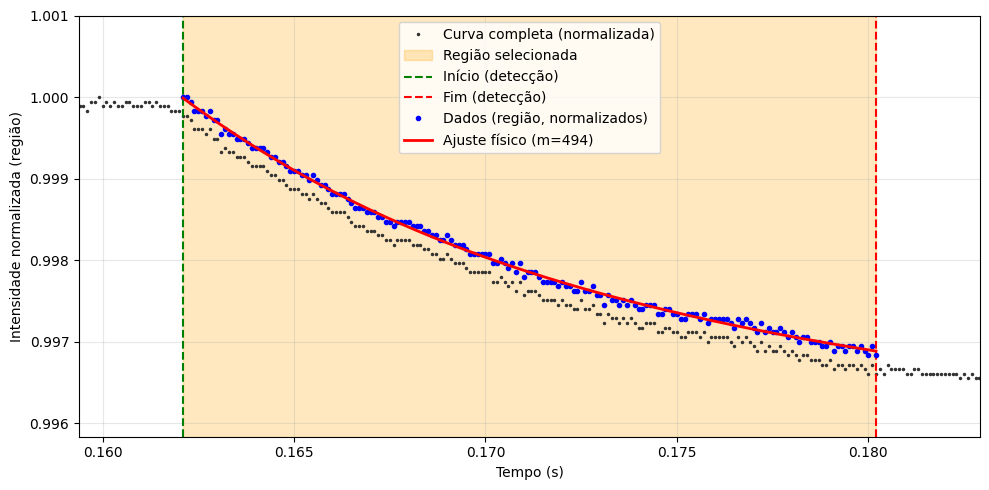

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

# ----------------------------
# 1) Leitura robusta (vírgula decimal aceita)
# ----------------------------
def read_oscilloscope_data_br(filename):
    t_list, I_list = [], []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            s = s.replace(',', '.')
            parts = s.split('\t')
            if len(parts) < 2:
                # tenta separar por espaços se não for tab
                parts = s.split()
            if len(parts) >= 2:
                try:
                    t_list.append(float(parts[0]))
                    I_list.append(float(parts[1]))
                except:
                    continue
    return np.array(t_list), np.array(I_list)

# ----------------------------
# 2) Modelo físico (sua equação)
#    usamos t_rel = t - t_start + eps internamente para evitar t=0
# ----------------------------
def thermal_lens_model_physical(t, I0, te, tc, m, V=1.73, eps=1e-9):
    # t is absolute time array passed in for the region
    t_rel = np.maximum(t - t[0], eps)  # garante > 0
    numerator = 2.0 * m * V
    # monta denominator com proteção numérica
    denom = ((1.0 + 2.0*m)**2 + V**2) * (tc / (2.0 * t_rel)) + 1.0 + 2.0*m + V**2
    atan_term = np.arctan(numerator / denom)
    return I0 * (1.0 - (te / 2.0) * atan_term)**2

# ----------------------------
# 3) Seleção automática da região correta
# ----------------------------
def detect_decay_region(t, I,
                        smooth_window=51, polyorder=3,
                        pre_peak_ignore=3,
                        frac_min_deriv_for_start=0.35,
                        noise_mult_for_start=3.0,
                        consec_end=6,
                        stable_frac=0.12,
                        min_region_pts=25,
                        debug=False):
    """
    Retorna (start_idx, end_idx) tentando capturar:
      - início: primeiro ponto *após o pico* onde derivada fica suficientemente negativa
      - fim: primeiro ponto após início onde derivada fica próxima de zero por `consec_end` pontos
    Parâmetros ajustáveis fornecem robustez.
    """
    n = len(t)
    if n < 10:
        return 0, n-1

    # adapta janela de Savitzky-Golay (tem que ser ímpar e <= n-1)
    w = int(smooth_window)
    if w >= n:
        w = n-1 if (n-1)%2==1 else n-2
    if w < 5:
        w = 5
    if w % 2 == 0:
        w += 1

    I_smooth = savgol_filter(I, w, polyorder)

    # derivada numérica dI/dt
    dt = np.diff(t)
    dt[dt <= 0] = np.median(dt[dt>0]) if np.any(dt>0) else 1e-6
    deriv = np.gradient(I_smooth, t)

    # pico (máxima intensidade) e analisa derivada depois dele
    peak_idx = int(np.argmax(I_smooth))

    # estima ruído da derivada antes do pico (platô inicial)
    if peak_idx >= 5:
        noise_est = np.std(deriv[:peak_idx])
    else:
        noise_est = np.std(deriv)

    # derivada mínima (mais negativa) após o pico
    if peak_idx < n-2:
        min_deriv_after = np.min(deriv[peak_idx:])
    else:
        min_deriv_after = np.min(deriv)

    # define limiar para detectar início:
    # combina fração da queda máxima com ruído (para evitar detecção em flutuações)
    thr_from_min = min_deriv_after * frac_min_deriv_for_start  # negativo * frac -> negativo
    thr_from_noise = -noise_mult_for_start * noise_est        # negativo
    start_threshold = min(thr_from_min, thr_from_noise)  # mais conservador (mais negativo)
    if debug:
        print(f"peak_idx={peak_idx}, noise={noise_est:.3e}, min_deriv_after={min_deriv_after:.3e}, start_threshold={start_threshold:.3e}")

    # procura o primeiro índice após o pico onde deriv <= start_threshold
    candidates = np.where(deriv[peak_idx+pre_peak_ignore:] <= start_threshold)[0]
    if len(candidates) == 0:
        # fallback: acha o ponto de menor deriv (mais negativo) após o pico
        rel_idx_start = int(np.argmin(deriv[peak_idx+pre_peak_ignore:])) if peak_idx+pre_peak_ignore < n else 0
        start_idx = peak_idx + pre_peak_ignore + rel_idx_start
    else:
        start_idx = peak_idx + pre_peak_ignore + candidates[0]

    # --- encontrar fim: deriv volta a valores próximos de zero (estabiliza) ---
    # definimos um limiar de "quase zero" relativo à derivada máxima negativa
    stable_threshold = min_deriv_after * stable_frac  # menos negativo (próximo de zero)
    # buscamos sequência de 'consec_end' pontos com deriv >= stable_threshold
    end_idx = n - 1
    consec = 0
    for i in range(start_idx, n):
        if deriv[i] >= stable_threshold:
            consec += 1
        else:
            consec = 0
        if consec >= consec_end:
            end_idx = max(start_idx+1, i - consec_end + 1)
            break

    # garante que janela tenha comprimento mínimo; se curto, amplia para direita até ter min_region_pts
    if (end_idx - start_idx + 1) < min_region_pts:
        end_idx = min(n-1, start_idx + min_region_pts - 1)

    # último ajuste: se end_idx alcançou final e ainda curto, retrocede start_idx
    if (end_idx - start_idx + 1) < min_region_pts:
        extra = min_region_pts - (end_idx - start_idx + 1)
        start_idx = max(0, start_idx - extra)

    if debug:
        print(f"detected start_idx={start_idx}, end_idx={end_idx}, len={end_idx-start_idx+1}")

    return int(start_idx), int(end_idx)

# ----------------------------
# 4) Função principal: leitura -> detecção -> ajuste -> plot
# ----------------------------
def analyze_file_and_fit(filename,
                         V=1.73,
                         m_init=14.9484,
                         fit_bounds=([0.8, 1e-6, 1e-6, 0.1], [1.2, 0.5, 5.0, 500.0]),
                         debug=False,
                         plot_results=True):
    t, I = read_oscilloscope_data_br(filename)
    if len(t) == 0:
        raise RuntimeError("Nenhum dado válido lido.")

    # normaliza inteira para ajudar visualização; ajuste será feito na região
    I = I / np.max(I)

    # detectar região automaticamente
    s_idx, e_idx = detect_decay_region(t, I, debug=debug)

    # extrai e normaliza região (normaliza ao primeiro ponto da região)
    t_region = t[s_idx:e_idx+1]
    I_region = I[s_idx:e_idx+1]
    if len(t_region) < 6:
        raise RuntimeError("Região de ajuste muito curta.")

    I_region = I_region / I_region[0]  # normaliza localmente

    # proteção / deslocamento de tempo dentro do modelo (usa t_region internamente)
    # p0 para ajuste baseado em escalas razoáveis (te, tc em s)
    p0 = [1.0, 0.01, 0.05, m_init]

    # ajuste com seu modelo físico; note que thermal_lens_model_physical
    # espera t array onde t[0] é início da região (tratamos t_rel internamente)
    try:
        popt, pcov = curve_fit(lambda tt, I0, te, tc, m: thermal_lens_model_physical(tt, I0, te, tc, m, V=V),
                               t_region, I_region, p0=p0, bounds=fit_bounds, maxfev=50000)
    except Exception as e:
        # tentativa de recuperação: ajustar primeiros com m fixo (mais estável) e então liberar m
        if debug:
            print("Ajuste direto falhou:", e, "Tentando ajuste em dois passos (m fixo -> libera m).")
        # passo 1: m fixo
        try:
            popt1, _ = curve_fit(lambda tt, I0, te, tc: thermal_lens_model_physical(tt, I0, te, tc, m_init, V=V),
                                 t_region, I_region, p0=[1.0, 0.01, 0.05], bounds=(fit_bounds[0][:3], fit_bounds[1][:3]), maxfev=30000)
            I0_1, te_1, tc_1 = popt1
            # passo 2: libera m em torno do m_init
            p0b = [I0_1, te_1, tc_1, m_init]
            lower = [max(0.5, I0_1*0.5), te_1*0.2, tc_1*0.2, 0.1]
            upper = [1.5, te_1*5, tc_1*5, 500.0]
            popt, pcov = curve_fit(lambda tt, I0, te, tc, m: thermal_lens_model_physical(tt, I0, te, tc, m, V=V),
                                   t_region, I_region, p0=p0b, bounds=(lower, upper), maxfev=50000)
        except Exception as e2:
            raise RuntimeError(f"Ajuste falhou (tentativa de recuperação também): {e2}")

    I0_fit, te_fit, tc_fit, m_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # calcula predição na região e R2
    I_pred = thermal_lens_model_physical(t_region, *popt, V=V)
    ss_res = np.sum((I_region - I_pred)**2)
    ss_tot = np.sum((I_region - np.mean(I_region))**2)
    R2 = 1.0 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # Impressão de resultados
    print("\n=== ANÁLISE DE LENTE TÉRMICA (m VARIÁVEL) ===")
    print(f"Arquivo: {filename}")
    print(f"Região usada: idx {s_idx} → {e_idx}, t = {t_region[0]:.6f} → {t_region[-1]:.6f} s ({len(t_region)} pontos)")
    print(f"I0 = {I0_fit:.6f} ± {perr[0]:.6f}")
    print(f"te = {te_fit:.6f} ± {perr[1]:.6f}")
    print(f"tc = {tc_fit:.6f} ± {perr[2]:.6f}")
    print(f"m  = {m_fit:.6f} ± {perr[3]:.6f}")
    print(f"R² = {R2:.5f}")

    # Plot diagnóstico
    if plot_results:
        plt.figure(figsize=(10,5))
        plt.plot(t, I, '.', color='0.2', markersize=3, label='Curva completa (normalizada)')
        plt.axvspan(t[s_idx], t[e_idx], color='orange', alpha=0.25, label='Região selecionada')
        plt.axvline(t[s_idx], color='green', linestyle='--', label='Início (detecção)')
        plt.axvline(t[e_idx], color='red', linestyle='--', label='Fim (detecção)')
        plt.plot(t_region, I_region, 'b.', label='Dados (região, normalizados)')
        plt.plot(t_region, I_pred, 'r-', lw=2, label=f'Ajuste físico (m={m_fit:.3g})')
        plt.xlabel('Tempo (s)')
        plt.ylabel('Intensidade normalizada (região)')
        plt.legend()
        plt.grid(alpha=0.3)
        # zoom inteligente: centraliza na região com uma margem
        margin = (t_region[-1] - t_region[0]) * 0.15
        plt.xlim(max(t[0], t_region[0]-margin), min(t[-1], t_region[-1]+margin))
        miny = min(np.min(I_region), np.min(I_pred))
        maxy = max(np.max(I_region), np.max(I_pred))
        plt.ylim(miny - 0.001*abs(miny), maxy + 0.001*abs(maxy))
        plt.tight_layout()
        plt.show()

    return {
        'I0': I0_fit, 'te': te_fit, 'tc': tc_fit, 'm': m_fit,
        'I0_err': perr[0], 'te_err': perr[1], 'tc_err': perr[2], 'm_err': perr[3],
        'R2': R2, 'region_idx': (s_idx, e_idx), 't_region': t_region, 'I_region': I_region
    }

# ----------------------------
# Execução (mude filename se precisar)
# ----------------------------
if __name__ == "__main__":
    res = analyze_file_and_fit("66.txt", V=1.73, m_init=14.9484, debug=True, plot_results=True)
